In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/
!rm -rf FAIMDL_PROJECT
!git clone https://github.com/raiwrd/FAIMDL_PROJECT.git
%cd /content/FAIMDL_PROJECT/eomt
!pip install -r requirements.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
Cloning into 'FAIMDL_PROJECT'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 131 (delta 22), reused 19 (delta 19), pack-reused 75 (from 1)
Receiving objects: 100% (131/131), 26.88 MiB | 11.50 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/FAIMDL_PROJECT/eomt


# Setup

In [ ]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config_path = "/content/FAIMDL_PROJECT/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
data_path = "/content/drive/MyDrive/FAIMDL_PROJECT/cityscapes"

with open(config_path, "r") as f:
    config = yaml.safe_load(f)


# Load dataset

In [ ]:
data_module_name, class_name = config["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config["data"].get("init_args", {})

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
).setup()

# Instantiate validation loader
val_loader = data.val_dataloader()

# Load model

In [ ]:
warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

# Load encoder
encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))

# Load network
network_cfg = config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=data.num_classes,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

model = (
    lit_cls(
        img_size=data.img_size,
        num_classes=data.num_classes,
        network=network,
        **model_kwargs,
    )
    .eval()
    .to(device)
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

# Load pretrained Weights

In [ ]:
import os
import warnings
import torch

name = config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name")

if name is None:
    warnings.warn("No logger name found in the config. Please specify a model name.")
else:
    my_drive_weights = "/content/drive/MyDrive/FAIMDL_PROJECT/checkpoints/eomt_cityscapes.bin"

    if os.path.exists(my_drive_weights):
        state_dict_path = my_drive_weights
        print(f"Weights are on Google Drive: {state_dict_path}")

        is_dinov3 = "dinov3" in name

        if is_dinov3:
            model_kwargs["ckpt_path"] = state_dict_path
            model_kwargs["delta_weights"] = True

        # Initialization
        model = (
            lit_cls(
                img_size=data.img_size,
                num_classes=data.num_classes,
                network=network,
                **model_kwargs,
            )
            .eval()
            .to(device)
        )

        # Weights loading
        if not is_dinov3:
            state_dict = torch.load(
                state_dict_path, map_location=device, weights_only=True
            )
            model.load_state_dict(state_dict, strict=False)
            print("-> Pesi reali caricati nel modello con successo! Ora è pronto.")

    else:
        raise FileNotFoundError(
            f"ERRORE: Impossibile trovare il file in '{my_drive_weights}'. "
            f"Verifica che le cartelle su Drive si chiamino esattamente così."
        )

Weights are on Google Drive: /content/drive/MyDrive/FAIMDL_PROJECT/checkpoints/eomt_cityscapes.bin
-> Pesi reali caricati nel modello con successo! Ora è pronto.


# iouEval Explanations

To use iouEval.py, located in eval folder, we need both the input image and target [1, 1, H, W], where each pixel has as value a class index


In [ ]:
def infer_semantic_with_model_and_imgsize(model_obj, img, model_img_size):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        img_single = img.squeeze(0) if img.dim() == 4 else img
        imgs = [img_single.to(device)]
        img_sizes = [img_single.shape[-2:] for img in imgs]

        crops, origins = model_obj.window_imgs_semantic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_obj(crops)

        mask_logits = F.interpolate(
            mask_logits_per_layer[-1],
            model_img_size,
            mode="bilinear",
            align_corners=False,
        )

        crop_logits = model_obj.to_per_pixel_logits_semantic(
            mask_logits,
            class_logits_per_layer[-1]
        )

        logits = model_obj.revert_window_logits_semantic(
            crop_logits, origins, img_sizes
        )

        preds = logits[0].argmax(0).cpu()
        return preds.unsqueeze(0).unsqueeze(0)

# Further explanations - DataLoader


*   batch[0]-> imgs, batch[1]-> tuple with a dictionary inside
*   batch[0]: list of imgs(1 in our case), batch[0][0] to access the img ([C,H,W])
*   dictionary: batch[1][0], dictionary example: {'masks': ..., 'labels': ..., 'is_crowd': ...}. The target parser funcion gives as a result [N, H, W], where N is the number of masks that it found (it can be lower than the number of classes)

We need to make the target of the same dimension of the output ([1,1,H,W])

(look at eval folder to understand better)

In [ ]:
# ============================================================
# Common evaluation pipeline for BOTH models
# Common label space: Cityscapes-19
# ============================================================

import os
import time
import torch
import yaml
import importlib
import warnings
import numpy as np

CITYSCAPES_CLASS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic light", "traffic sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train", "motorcycle", "bicycle"
]

IGNORE_LABEL = 19  # same convention used in your notebook

def build_gt_from_batch(batch, ignore_label=IGNORE_LABEL):
    raw_target = batch[1]
    data_dict = raw_target[0]
    masks = data_dict["masks"]
    train_ids = data_dict["labels"]

    H, W = masks.shape[-2], masks.shape[-1]
    gt_labels = torch.full((1, H, W), ignore_label, dtype=torch.long)

    for i in range(len(masks)):
        mask = masks[i]
        t_id = int(train_ids[i])
        if 0 <= t_id <= 18:
            gt_labels[0, mask] = t_id

    return gt_labels.unsqueeze(0)  # [1,1,H,W]

def build_model_from_config(config_path, ckpt_path, data, device):
    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)

    warnings.filterwarnings(
        "ignore",
        message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
    )

    # encoder
    encoder_cfg = cfg["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
    encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))

    # network
    network_cfg = cfg["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}

    network = network_cls(
        masked_attn_enabled=False,
        num_classes=data.num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # lightning module
    lit_module_name, lit_class_name = cfg["model"]["class_path"].rsplit(".", 1)
    lit_cls_local = getattr(importlib.import_module(lit_module_name), lit_class_name)

    model_kwargs_local = {k: v for k, v in cfg["model"]["init_args"].items() if k != "network"}
    if "stuff_classes" in cfg["data"].get("init_args", {}):
        model_kwargs_local["stuff_classes"] = cfg["data"]["init_args"]["stuff_classes"]

    model_local = (
        lit_cls_local(
            img_size=data.img_size,
            num_classes=data.num_classes,
            network=network,
            **model_kwargs_local,
        )
        .eval()
        .to(device)
    )

    state_dict = torch.load(ckpt_path, map_location=device, weights_only=True)
    model_local.load_state_dict(state_dict, strict=False)

    return model_local, cfg

def infer_semantic_with_model(model_obj, img):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        img_single = img.squeeze(0) if img.dim() == 4 else img
        imgs = [img_single.to(device)]
        img_sizes = [img_single.shape[-2:] for img in imgs]

        crops, origins = model_obj.window_imgs_semantic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_obj(crops)

        mask_logits = F.interpolate(
            mask_logits_per_layer[-1],
            data.img_size,
            mode="bilinear",
            align_corners=False,
        )

        crop_logits = model_obj.to_per_pixel_logits_semantic(
            mask_logits,
            class_logits_per_layer[-1]
        )

        logits = model_obj.revert_window_logits_semantic(
            crop_logits, origins, img_sizes
        )  # [C,H,W]

        preds = logits[0].argmax(0).cpu()           # [H,W]
        outputs = preds.unsqueeze(0).unsqueeze(0)   # [1,1,H,W]
        return outputs

def remap_mask(preds, id_map, ignore_label=IGNORE_LABEL):
    remapped = torch.full_like(preds, ignore_label)
    for src_id, dst_id in id_map.items():
        remapped[preds == int(src_id)] = int(dst_id)
    return remapped

def evaluate_model(model_obj, model_name, prediction_adapter=None, print_every=100):
    iou_eval = iouEval(data.num_classes + 1, ignoreIndex=IGNORE_LABEL)
    start = time.time()

    print(f"\nValidation - {model_name}")

    for step, batch in enumerate(val_loader, start=1):
        images = batch[0][0]
        gt_labels = build_gt_from_batch(batch)

        pred = infer_semantic_with_model(model_obj, images)

        if prediction_adapter is not None:
            pred = prediction_adapter(pred)

        iou_eval.addBatch(pred, gt_labels)

        if step % print_every == 0:
            print(f"Step: {step}")

    iou_val, iou_classes = iou_eval.getIoU()

    print("---------------------------------------")
    print("Took", time.time() - start, "seconds")
    print("=======================================")
    print(f"Per-Class IoU - {model_name}:")
    for i, cls_name in enumerate(CITYSCAPES_CLASS_NAMES):
        print(f"{cls_name:15s}: {float(iou_classes[i] * 100):6.2f}")
    print("=======================================")
    print(f"MEAN IoU - {model_name}: {float(iou_val * 100):.2f}%")

    return {
        "name": model_name,
        "miou": float(iou_val),
        "per_class_iou": iou_classes.cpu().numpy()
    }

In [ ]:
# ============================================================
# LOAD THE SECOND MODEL (COCO-trained)
# ============================================================

import math
import torch
import yaml
import importlib
import warnings
import torch.nn.functional as F

config_path_coco = "/content/FAIMDL_PROJECT/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
ckpt_path_coco   = "/content/drive/MyDrive/FAIMDL_PROJECT/checkpoints/eomt_coco.bin"

def infer_num_classes_from_coco_panoptic_config(cfg):
    stuff_classes = cfg["data"]["init_args"].get("stuff_classes", [])
    if len(stuff_classes) == 53:
        return 133   # standard COCO panoptic semantic categories
    return max(stuff_classes) + 1 if len(stuff_classes) > 0 else 133

def resize_abs_pos_embed(pos_embed_ckpt, pos_embed_model):
    if pos_embed_ckpt.shape == pos_embed_model.shape:
        return pos_embed_ckpt

    # expected shapes: [1, N, C]
    _, n_old, c = pos_embed_ckpt.shape
    _, n_new, c2 = pos_embed_model.shape
    assert c == c2, "Embedding dim mismatch in pos_embed"

    gs_old = int(math.sqrt(n_old))
    gs_new = int(math.sqrt(n_new))

    if gs_old * gs_old != n_old or gs_new * gs_new != n_new:
        print(f"Skipping pos_embed resize: old={pos_embed_ckpt.shape}, new={pos_embed_model.shape}")
        return None

    pe = pos_embed_ckpt.reshape(1, gs_old, gs_old, c).permute(0, 3, 1, 2)   # [1,C,H,W]
    pe = F.interpolate(pe, size=(gs_new, gs_new), mode="bicubic", align_corners=False)
    pe = pe.permute(0, 2, 3, 1).reshape(1, gs_new * gs_new, c)
    return pe

def build_coco_model_from_config(config_path, ckpt_path, device):
    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)

    warnings.filterwarnings(
        "ignore",
        message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
    )

    coco_num_classes = infer_num_classes_from_coco_panoptic_config(cfg)
    print("COCO inferred num_classes:", coco_num_classes)

    # Build encoder
    encoder_cfg = cfg["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)

    encoder = encoder_cls(
        img_size=(640, 640), ###FIXME 640
        **encoder_cfg.get("init_args", {})
    )

    # Build network
    network_cfg = cfg["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}

    network = network_cls(
        masked_attn_enabled=False,
        num_classes=coco_num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # Build Lightning module
    lit_module_name, lit_class_name = cfg["model"]["class_path"].rsplit(".", 1)
    lit_cls_local = getattr(importlib.import_module(lit_module_name), lit_class_name)

    model_kwargs_local = {k: v for k, v in cfg["model"]["init_args"].items() if k != "network"}
    if "stuff_classes" in cfg["data"].get("init_args", {}):
        model_kwargs_local["stuff_classes"] = cfg["data"]["init_args"]["stuff_classes"]

    model_local = (
        lit_cls_local(
            img_size=(640, 640), ###FIXME 640
            num_classes=coco_num_classes,
            network=network,
            **model_kwargs_local,
        )
        .eval()
        .to(device)
    )

    # Load checkpoint and filter incompatible tensors
    state_dict = torch.load(ckpt_path, map_location=device, weights_only=True)
    model_state = model_local.state_dict()

    filtered_state = {}
    skipped = []

    for k, v in state_dict.items():
        if k not in model_state:
            skipped.append((k, "missing_in_model"))
            continue

        if v.shape == model_state[k].shape:
            filtered_state[k] = v
            continue

        if k.endswith("network.encoder.backbone.pos_embed"):
            resized = resize_abs_pos_embed(v, model_state[k])
            if resized is not None and resized.shape == model_state[k].shape:
                filtered_state[k] = resized
                print(f"Resized pos_embed: {tuple(v.shape)} -> {tuple(resized.shape)}")
            else:
                skipped.append((k, f"shape_mismatch {tuple(v.shape)} != {tuple(model_state[k].shape)}"))
            continue

        skipped.append((k, f"shape_mismatch {tuple(v.shape)} != {tuple(model_state[k].shape)}"))

    missing, unexpected = model_local.load_state_dict(filtered_state, strict=False)

    print("\nLoaded filtered checkpoint.")
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))
    print("Skipped keys:", len(skipped))

    for item in skipped[:20]:
        print(" -", item)

    return model_local, cfg, coco_num_classes

model_coco, config_coco, coco_num_classes = build_coco_model_from_config(
    config_path=config_path_coco,
    ckpt_path=ckpt_path_coco,
    device=device
)

print("COCO model loaded correctly.")

COCO inferred num_classes: 133

Loaded filtered checkpoint.
Missing keys: 0
Unexpected keys: 0
Skipped keys: 0
COCO model loaded correctly.


In [ ]:
# ============================================================
# COCO PANOPTIC -> CITYSCAPES MAPPING
# ============================================================

COCO_TO_CITYSCAPES = {
    # ── THINGS ────────────────────
    0:   11,  # person        -> person
    1:   18,  # bicycle       -> bicycle
    2:   13,  # car           -> car
    3:   17,  # motorcycle    -> motorcycle
    # 5: airplane  -> ignore
    5:   15,  # bus           -> bus
    6:   16,  # train         -> train
    7:   14,  # truck         -> truck
    # 8: boat      -> ignore
    9:   6,  # traffic light -> traffic light
    # 10: fire hydrant  -> ignore
    11:   7,  # stop sign     -> traffic sign  (approx)
    # 12: parking meter -> ignore
    # 13-79: other things -> ignore

    # ── STUFF ────────────────────
    # contiguous 80=banner -> real 92   -> ignore
    # contiguous 82=bridge -> real 94   -> ignore
    # contiguous 86=door-stuff -> real 98 -> ignore
    # contiguous 87=floor-wood -> real 99 -> ignore
    # contiguous 90=gravel -> real 102  -> ignore
    91:   2,  # house              -> building
    92:   5,  # light              -> pole (closest approx)
    # 93: mirror-stuff -> ignore
    # 96: platform -> ignore
    # 97: playingfield -> ignore
    98:  10,  # railroad (rail tracks visible -> terrain approx) -> terrain
    # 99: river -> ignore
    100:  0,  # road               -> road
    # 101: roof -> ignore
    102:  9,  # sand               -> terrain
    # 103: sea -> ignore
    # 104: shelf -> ignore
    # 105: snow -> terrain (optional)
    # 106: stairs -> ignore
    # 107: tent -> ignore
    109:  3,  # wall-brick         -> wall
    110:  3,  # wall-stone         -> wall
    111:  3,  # wall-tile          -> wall
    112:  3,  # wall-wood          -> wall
    # 113: water-other -> ignore
    # 114: window-blind -> ignore
    # 115: window-other -> ignore
    116:  8,  # tree-merged        -> vegetation
    117:  4,  # fence-merged       -> fence
    # 118: ceiling-merged -> ignore
    119: 10,  # sky-other-merged   -> sky
    # 120: cabinet-merged -> ignore
    # 121: table-merged -> ignore
    # 122: floor-other-merged -> ignore
    123:  1,  # pavement-merged    -> sidewalk
    124:  9,  # mountain-merged    -> terrain
    125:  8,  # grass-merged       -> vegetation
    126:  9,  # dirt-merged        -> terrain
    # 127: paper-merged -> ignore
    # 128: food-other-merged -> ignore
    129:  2,  # building-other-merged -> building
    130:  9,  # rock-merged        -> terrain
    131:  3,  # wall-other-merged  -> wall
    # 132: rug-merged -> ignore
}

def coco_to_cityscapes_adapter(pred):
    return remap_mask(pred, COCO_TO_CITYSCAPES, ignore_label=IGNORE_LABEL)

In [ ]:
import numpy as np
import sys
sys.path.append('/content/FAIMDL_PROJECT/eval')
from iouEval import iouEval, getColorEntry

def evaluate_model(model_obj, model_name, prediction_adapter=None, print_every=100, model_img_size=None):
    iou_eval = iouEval(data.num_classes + 1, ignoreIndex=IGNORE_LABEL)
    start = time.time()

    print(f"\nValidation - {model_name}")

    for step, batch in enumerate(val_loader, start=1):
        images = batch[0][0]
        gt_labels = build_gt_from_batch(batch)

        if model_img_size is None:
            pred = infer_semantic_with_model(model_obj, images)
        else:
            pred = infer_semantic_with_model_and_imgsize(model_obj, images, model_img_size)

        if prediction_adapter is not None:
            pred = prediction_adapter(pred)

        iou_eval.addBatch(pred, gt_labels)

        if step % print_every == 0:
            print(f"Step: {step}")

    iou_val, iou_classes = iou_eval.getIoU()

    print("---------------------------------------")
    print("Took", time.time() - start, "seconds")
    print("=======================================")
    print(f"Per-Class IoU - {model_name}:")
    for i, cls_name in enumerate(CITYSCAPES_CLASS_NAMES):
        print(f"{cls_name:15s}: {float(iou_classes[i] * 100):6.2f}")
    print("=======================================")
    print(f"MEAN IoU - {model_name}: {float(iou_val * 100):.2f}%")

    return {
        "name": model_name,
        "miou": float(iou_val),
        "per_class_iou": iou_classes.cpu().numpy()
    }

In [ ]:
# ============================================================
# FINAL FAIR EVALUATION
# ============================================================


results_city = evaluate_model(
    model_obj=model,
    model_name="Cityscapes model",
    prediction_adapter=None,
    print_every=100,
    model_img_size=None
)


if isinstance(model_coco.img_size, int):
    model_coco.img_size = (model_coco.img_size, model_coco.img_size)

results_coco = evaluate_model(
    model_obj=model_coco,
    model_name="COCO panoptic model mapped to Cityscapes",
    model_img_size=(640, 640),
    prediction_adapter=coco_to_cityscapes_adapter,
    print_every=100,
)

print("\n================ FINAL COMPARISON ================\n")
print(f"Cityscapes model mIoU: {results_city['miou'] * 100:.2f}")
print(f"COCO model mIoU      : {results_coco['miou'] * 100:.2f}")



Validation - Cityscapes model
Step: 100
Step: 200
Step: 300
Step: 400
Step: 500
---------------------------------------
Took 948.0108315944672 seconds
Per-Class IoU - Cityscapes model:
road           :  98.40
sidewalk       :  87.36
building       :  94.15
wall           :  66.07
fence          :  65.49
pole           :  71.04
traffic light  :  75.00
traffic sign   :  82.13
vegetation     :  93.02
terrain        :  66.60
sky            :  95.54
person         :  85.38
rider          :  71.11
car            :  95.54
truck          :  81.79
bus            :  90.32
train          :  77.35
motorcycle     :  74.35
bicycle        :  81.27
MEAN IoU - Cityscapes model: 81.68%

Validation - COCO panoptic model mapped to Cityscapes
Step: 100
Step: 200
Step: 300
Step: 400
Step: 500
---------------------------------------
Took 931.1854848861694 seconds
Per-Class IoU - COCO panoptic model mapped to Cityscapes:
road           :  94.01
sidewalk       :  64.74
building       :  84.04
wall           :

In [ ]:
# ============================================================
# STEP 5 - FINE-TUNING COCO -> CITYSCAPES
# Strategy: warm start from COCO checkpoint
#           Phase 1: freeze backbone, train head only
#           Phase 2 (optional): unfreeze last layers
# ============================================================

import os, math, time, yaml, torch, warnings, importlib
import lightning as L
import torch.nn.functional as F
from torch.amp.autocast_mode import autocast
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger

warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing.*"
)

# ── PATHS ────────────────────────────────────────────────────
config_path_coco  = "/content/FAIMDL_PROJECT/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
config_path_city  = "/content/FAIMDL_PROJECT/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
coco_ckpt_path    = "/content/drive/MyDrive/FAIMDL_PROJECT/checkpoints/eomt_coco.bin"
data_path         = "/content/drive/MyDrive/FAIMDL_PROJECT/cityscapes"
save_dir          = "/content/drive/MyDrive/FAIMDL_PROJECT/finetune_coco_to_cityscapes"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
import yaml
import importlib

# ── DATAMODULE CITYSCAPES (train + val) ──────────────────────
with open(config_path_city, "r") as f:
    cfg_city = yaml.safe_load(f)

dm_name, dm_cls_name = cfg_city["data"]["class_path"].rsplit(".", 1)
dm_cls = getattr(importlib.import_module(dm_name), dm_cls_name)
dm_kwargs = cfg_city["data"].get("init_args", {})

data_ft = dm_cls(
    path=data_path,
    batch_size=2,
    num_workers=2,
    check_empty_targets=False,
    img_size=(640, 640),                          # Force 640x640 to match fine-tuning requirements
    **{k: v for k, v in dm_kwargs.items() if k != 'img_size'}
)
data_ft.setup()

print("Cityscapes train datamodule ready.")
print("num_classes:", data_ft.num_classes)        # should be 19
print("img_size:   ", data_ft.img_size)

Cityscapes train datamodule ready.
num_classes: 19
img_size:    (640, 640)


In [ ]:
import importlib
import torch

# ── BUILD MODEL: Cityscapes head, COCO backbone weights ──────

# Encoder — patch_size=14, img_size=640
encoder_cfg = cfg_city["model"]["init_args"]["network"]["init_args"]["encoder"]
enc_mod, enc_cls_name = encoder_cfg["class_path"].rsplit(".", 1)
enc_cls = getattr(importlib.import_module(enc_mod), enc_cls_name)
encoder_ft = enc_cls(img_size=(640, 640), **encoder_cfg.get("init_args", {}))

# Network
net_cfg = cfg_city["model"]["init_args"]["network"]
net_mod, net_cls_name = net_cfg["class_path"].rsplit(".", 1)
net_cls = getattr(importlib.import_module(net_mod), net_cls_name)
net_kwargs = {k: v for k, v in net_cfg["init_args"].items() if k != "encoder"}

network_ft = net_cls(
    masked_attn_enabled=False,
    num_classes=data_ft.num_classes,   # 19
    encoder=encoder_ft,
    **net_kwargs,
)

# Lightning module
lit_mod, lit_cls_name = cfg_city["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_mod), lit_cls_name)
model_kwargs_ft = {k: v for k, v in cfg_city["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in cfg_city["data"].get("init_args", {}):
    model_kwargs_ft["stuff_classes"] = cfg_city["data"]["init_args"]["stuff_classes"]

model_ft = lit_cls(
    img_size=(640, 640),
    num_classes=data_ft.num_classes,
    network=network_ft,
    **model_kwargs_ft,
)

# ── LOAD COCO WEIGHTS ───
coco_state  = torch.load(coco_ckpt_path, map_location="cpu", weights_only=True)
model_state = model_ft.state_dict()

filtered, skipped = {}, []
for k, v in coco_state.items():
    if k not in model_state:
        skipped.append((k, "missing")); continue
    if tuple(v.shape) == tuple(model_state[k].shape):
        filtered[k] = v
    else:
        skipped.append((k, f"shape {tuple(v.shape)} != {tuple(model_state[k].shape)}"))

missing, unexpected = model_ft.load_state_dict(filtered, strict=False)
print(f"Transferred: {len(filtered)} tensors")
print(f"Missing    : {len(missing)}")
print(f"Skipped    : {len(skipped)}")

Transferred: 194 tensors
Missing    : 4
Skipped    : 4


In [ ]:
# ── PHASE 1: FREEZE backbone, train ONLY the prediction head ─
HEAD_KEYWORDS = ["class_head", "mask_head", "upscale", "q.weight"]

def set_trainable(model, head_keywords):
    frozen, trainable = 0, 0
    for name, param in model.named_parameters():
        if any(kw in name for kw in head_keywords):
            param.requires_grad = True
            trainable += 1
        else:
            param.requires_grad = False
            frozen += 1
    print(f"Trainable params: {trainable} | Frozen params: {frozen}")

set_trainable(model_ft, HEAD_KEYWORDS)

print("\nTrainable layers (sample):")
for name, p in model_ft.named_parameters():
    if p.requires_grad:
        print(f"  {name}")

Trainable params: 19 | Frozen params: 175

Trainable layers (sample):
  network.q.weight
  network.class_head.weight
  network.class_head.bias
  network.mask_head.0.weight
  network.mask_head.0.bias
  network.mask_head.2.weight
  network.mask_head.2.bias
  network.mask_head.4.weight
  network.mask_head.4.bias
  network.upscale.0.conv1.weight
  network.upscale.0.conv1.bias
  network.upscale.0.conv2.weight
  network.upscale.0.norm.weight
  network.upscale.0.norm.bias
  network.upscale.1.conv1.weight
  network.upscale.1.conv1.bias
  network.upscale.1.conv2.weight
  network.upscale.1.norm.weight
  network.upscale.1.norm.bias


In [ ]:
from google.colab import userdata
import wandb
import os


os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Currently logged in as: cristinagenduso (cristinagenduso-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
from lightning.pytorch.loggers import WandbLogger, CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor, Callback
import lightning as L
import torch
import time
import os

if hasattr(model_ft, "lr"):
    model_ft.lr = 1e-4
if hasattr(model_ft, "learning_rate"):
    model_ft.learning_rate = 1e-4

# Force hyperparameter consistency to prevent merging error
if hasattr(model_ft, "hparams"):
    model_ft.hparams.img_size = (640, 640)
if hasattr(data_ft, "hparams"):
    data_ft.hparams.img_size = (640, 640)

print("hparams nel modello:", model_ft.hparams.get('img_size'))
print("hparams nel datamodule:", data_ft.hparams.get('img_size'))

class TimingCallback(Callback):
    def on_fit_start(self, trainer, pl_module):
        self.t0 = time.time()
        print("\n[TRAIN] Fit started")

    def on_train_epoch_start(self, trainer, pl_module):
        self.epoch_t0 = time.time()
        print(f"\n[TRAIN] Epoch {trainer.current_epoch + 1}/{trainer.max_epochs} started")

    def on_train_epoch_end(self, trainer, pl_module):
        dt = time.time() - self.epoch_t0
        print(f"[TRAIN] Epoch {trainer.current_epoch + 1} ended in {dt/60:.2f} min")

checkpoint_cb = ModelCheckpoint(
    dirpath=save_dir,
    filename="phase1-{epoch:02d}-{val_miou:.4f}",
    save_top_k=2,
    monitor="metrics/val_iou_all",
    mode="max",
    save_last=True,
)

lr_monitor = LearningRateMonitor(logging_interval="epoch")
wandb_logger = WandbLogger(project="faimdl", name="phase1-head-only", save_dir=save_dir)

trainer = L.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_epochs=15,
    precision="16-mixed" if torch.cuda.is_available() else "32-true",
    logger=wandb_logger,
    callbacks=[checkpoint_cb, lr_monitor, TimingCallback()],
    log_every_n_steps=20,
    val_check_interval=1.0,
    gradient_clip_val=1.0,
)

print("Starting Phase 1 fine-tuning...")
trainer.fit(model_ft, datamodule=data_ft, ckpt_path="/content/drive/MyDrive/FAIMDL_PROJECT/finetune_coco_to_cityscapes/last.ckpt")

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: `Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
INFO:lightning.pytorch.utilities.rank_zero:`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


hparams nel modello: (640, 640)
hparams nel datamodule: (640, 640)
Starting Phase 1 fine-tuning...


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /content/drive/MyDrive/FAIMDL_PROJECT/finetune_coco_to_cityscapes exists and is not empty.
INFO: Restoring states from the checkpoint path at /content/drive/MyDrive/FAIMDL_PROJECT/finetune_coco_to_cityscapes/last.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/FAIMDL_PROJECT/finetune_coco_to_cityscapes/last.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
INFO: 
  | Name      | Type                   | Params | Mode 
-------------------------------------------------------------
0 | network   | EoMT                   | 93.5 M | train
1 | crite


[TRAIN] Fit started


INFO: Restored all states from the checkpoint at /content/drive/MyDrive/FAIMDL_PROJECT/finetune_coco_to_cityscapes/last.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restored all states from the checkpoint at /content/drive/MyDrive/FAIMDL_PROJECT/finetune_coco_to_cityscapes/last.ckpt


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


In [ ]:
best_ckpt = checkpoint_cb.best_model_path
print("Loading:", best_ckpt)

# Reconstruct the best model
encoder_eval = enc_cls(img_size=(640, 640), **encoder_cfg.get("init_args", {}))
network_eval = net_cls(
    masked_attn_enabled=False,
    num_classes=data_ft.num_classes,
    encoder=encoder_eval,
    **net_kwargs,
)
model_ft_eval = lit_cls(
    img_size=(640, 640),
    num_classes=data_ft.num_classes,
    network=network_eval,
    **model_kwargs_ft,
).eval().to(device)


ckpt_data = torch.load(best_ckpt, map_location=device, weights_only=False)
state = ckpt_data.get("state_dict", ckpt_data)
model_ft_eval.load_state_dict(state, strict=False)

Loading: /content/drive/MyDrive/FAIMDL_PROJECT/finetune_coco_to_cityscapes/phase1-epoch=14-val_miou=0.0000.ckpt


<All keys matched successfully>

In [ ]:
# We evaluate with the same pipeline of step 4
results_ft = evaluate_model(
    model_obj=model_ft_eval,
    model_name="Fine-tuned COCO->Cityscapes (head only)",
    model_img_size=(640, 640), # Changed from None to (640, 640)
    prediction_adapter=None,
    print_every=100,
)

# Final comparison
print("\n================ STEP 5 COMPARISON ================")
print(f"Cityscapes baseline (provided)  : {results_city['miou'] * 100:.2f}%")
print(f"COCO zero-shot mapped           : {results_coco['miou'] * 100:.2f}%")
print(f"COCO fine-tuned on Cityscapes   : {results_ft['miou'] * 100:.2f}%")

In [ ]:
import os, sys, json
import numpy as np
import torch
import torch.nn.functional as F
from torch.amp.autocast_mode import autocast
from PIL import Image
import torchvision.transforms as T
from tqdm import tqdm
from sklearn.metrics import average_precision_score, roc_curve

DATASETS_ROOT = '/content/drive/MyDrive/FAIMDL_PROJECT/Anomaly_Validation_Datasets'
CACHE_DIR     = '/content/drive/MyDrive/FAIMDL_PROJECT/anomaly_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

DATASET_CONFIGS = {
    "SMIYC_RA21": {
        "images":      os.path.join(DATASETS_ROOT, "RoadAnomaly21/images"),
        "masks":       os.path.join(DATASETS_ROOT, "RoadAnomaly21/labels_masks"),
        "mask_suffix": ".png",
    },
    "SMIYC_RO21": {
        "images":      os.path.join(DATASETS_ROOT, "RoadObstacle21/images"),
        "masks":       os.path.join(DATASETS_ROOT, "RoadObstacle21/labels_masks"),
        "mask_suffix": ".png",
    },
    "FS_Static": {
        "images":      os.path.join(DATASETS_ROOT, "fs_static/images"),
        "masks":       os.path.join(DATASETS_ROOT, "fs_static/labels_masks"),
        "mask_suffix": ".png",
    },
    "RoadAnomaly": {
        "images":      os.path.join(DATASETS_ROOT, "RoadAnomaly/images"),
        "masks":       os.path.join(DATASETS_ROOT, "RoadAnomaly/labels_masks"),
        "mask_suffix": ".png",
    },
    "FS_LnF": {
        "images":      os.path.join(DATASETS_ROOT, "FS_LostFound_full/images"),
        "masks":       os.path.join(DATASETS_ROOT, "FS_LostFound_full/labels_masks"),
        "mask_suffix": ".png",
    },
}

for ds_name, cfg in DATASET_CONFIGS.items():
    n = len(os.listdir(cfg["images"])) if os.path.isdir(cfg["images"]) else "✗ PATH NON TROVATO"
    print(f"  {ds_name:<15}: {n} immagini")

  SMIYC_RA21     : 10 immagini
  SMIYC_RO21     : 30 immagini
  FS_Static      : 30 immagini
  RoadAnomaly    : 60 immagini
  FS_LnF         : 100 immagini


In [ ]:
class AnomalyDataset(torch.utils.data.Dataset):
    IMG_MEAN = [0.485, 0.456, 0.406]
    IMG_STD  = [0.229, 0.224, 0.225]

    IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp")

    def __init__(self, images_dir, masks_dir, mask_suffix=".png"):
        self.image_paths = sorted([
            os.path.join(images_dir, f)
            for f in os.listdir(images_dir)
            if f.lower().endswith(self.IMG_EXTS)
        ])
        self.masks_dir   = masks_dir
        self.mask_suffix = mask_suffix
        self.transform   = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=self.IMG_MEAN, std=self.IMG_STD),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path  = self.image_paths[idx]
        stem      = os.path.splitext(os.path.basename(img_path))[0]
        mask_path = os.path.join(self.masks_dir, stem + self.mask_suffix)

        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask non trovata: {mask_path}")

        image = Image.open(img_path).convert("RGB")
        mask  = np.array(Image.open(mask_path))

        return self.transform(image), torch.from_numpy(mask).long(), stem

In [ ]:
# ── Metriche ──────────────────────────────────────────────────────────────────

def compute_metrics(scores: np.ndarray, labels: np.ndarray):
    """AuPRC e FPR@95TPR su array flat di scores e labels binari (0/1)."""
    auprc = average_precision_score(labels, scores)
    fpr, tpr, _ = roc_curve(labels, scores)
    idx   = np.searchsorted(tpr, 0.95)
    fpr95 = float(fpr[min(idx, len(fpr) - 1)])
    return round(auprc, 4), round(fpr95, 4)


# ── Score functions ─────────────────

def score_msp(logits, temperature=1.0):
    """Anomaly score = 1 – max_c softmax(logits/T)"""
    probs = F.softmax(logits / temperature, dim=1)
    return (1.0 - probs.max(dim=1).values).squeeze(0)   # (H, W)

def score_max_logit(logits, temperature=1.0):
    """Anomaly score = –max_c (logit_c / T)"""
    return (-(logits / temperature).max(dim=1).values).squeeze(0)

def score_max_entropy(logits, temperature=1.0):
    """Entropia normalizzata: H(softmax(logits/T)) / log(C)"""
    probs   = F.softmax(logits / temperature, dim=1)
    log_p   = F.log_softmax(logits / temperature, dim=1)
    entropy = -(probs * log_p).sum(dim=1)
    return (entropy / np.log(logits.shape[1])).squeeze(0)


# ── Helper EoMT ─────────────

def eomt_raw_to_sem_logits(mask_logits_raw, class_logits_raw, target_hw):
    """
    mask_logits_raw:  (Q, H, W) oppure (1, Q, H, W)
    class_logits_raw: (Q, C+1)  oppure (1, Q, C+1)
    """
    # normalizza a 4D
    ml = mask_logits_raw
    if ml.dim() == 3:
        ml = ml.unsqueeze(0)      # (1, Q, H, W)

    cl = class_logits_raw
    if cl.dim() == 2:
        cl = cl.unsqueeze(0)      # (1, Q, C+1)

    class_scores = F.softmax(cl[..., :-1], dim=-1)   # (1, Q, C)
    masks_up     = F.interpolate(ml, size=target_hw,
                                  mode="bilinear", align_corners=False)
    mask_prob    = masks_up.sigmoid()                 # (1, Q, H, W)

    # pixel logit = Σ_q class_score_q * mask_prob_q
    sem = torch.einsum("bqhw,bqc->bchw", mask_prob, class_scores)  # (1, C, H, W)
    return sem


def score_rba(mask_logits_raw, class_logits_raw, target_hw):
    """
    RbA – Rejected by All (Nayal et al., ICCV 2023).
    s_RbA(p) = –log Σ_q  max(0, σ(m_q(p))) * max(0, max_c p_class[q,c])
    """
    # normalizza a 4D
    ml = mask_logits_raw
    if ml.dim() == 3:
        ml = ml.unsqueeze(0)      # (1, Q, H, W)

    cl = class_logits_raw
    if cl.dim() == 2:
        cl = cl.unsqueeze(0)      # (1, Q, C+1)
    class_scores = F.softmax(cl[..., :-1], dim=-1)
    max_cls      = class_scores.max(dim=-1).values                  # (1,Q)
    masks_up     = F.interpolate(ml, size=target_hw,
                                 mode="bilinear", align_corners=False)
    mask_prob    = masks_up.sigmoid()
    support      = (mask_prob.clamp(min=0) *
                    max_cls.unsqueeze(-1).unsqueeze(-1).clamp(min=0)).sum(dim=1)
    return (-torch.log(support + 1e-6)).squeeze(0)                  # (H, W)

print("Metriche e score functions ✓")

Metriche e score functions ✓


In [ ]:
sys.path.insert(0, '/content/FAIMDL_PROJECT/eval')
from erfnet import ERFNet

ERFNET_WEIGHTS = '/content/FAIMDL_PROJECT/trained_models/erfnet_pretrained.pth'

# Checkpoint ERFNet contains 20 classes (19 + ignore)
erfnet = ERFNet(num_classes=20)

state_raw   = torch.load(ERFNET_WEIGHTS, map_location='cpu', weights_only=True)
state_clean = {k.replace('module.', ''): v for k, v in state_raw.items()}

missing, unexpected = erfnet.load_state_dict(state_clean, strict=False)

print(f"Missing keys   ({len(missing)}): {missing}")
print(f"Unexpected keys({len(unexpected)}): {unexpected}")

erfnet = erfnet.eval().to(device)
print("\nERFNet loaded ✓")

# ── STEP 7: inferenza e valutazione ──────────────────────────────────────────

import os, gc, json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from torch.amp.autocast_mode import autocast
from tqdm import tqdm

STEP7_CACHE_DIR = '/content/drive/MyDrive/FAIMDL_PROJECT/step7_cache'
STEP7_RESULTS = '/content/drive/MyDrive/FAIMDL_PROJECT/results_step7.json'
CHUNK_SIZE = 10

Path(STEP7_CACHE_DIR).mkdir(parents=True, exist_ok=True)

METHODS_STEP7 = {
    "MSP": score_msp,
    "MaxLogit": score_max_logit,
    "MaxEntropy": score_max_entropy,
}

def _dataset_cache_dir(ds_name):
    d = Path(STEP7_CACHE_DIR) / ds_name
    d.mkdir(parents=True, exist_ok=True)
    return d

def _chunk_path(ds_name, chunk_idx):
    return _dataset_cache_dir(ds_name) / f"chunk_{chunk_idx:04d}.npz"

def _meta_path(ds_name):
    return _dataset_cache_dir(ds_name) / "meta.json"

def process_dataset_to_chunks(ds_name, cfg):
    dataset = AnomalyDataset(cfg["images"], cfg["masks"], cfg["mask_suffix"])
    loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
    meta = {"num_samples": len(dataset), "num_chunks": 0, "chunk_size": CHUNK_SIZE}
    with open(_meta_path(ds_name), "w") as f:
        json.dump(meta, f, indent=2)

    chunk_scores = {m: [] for m in METHODS_STEP7}
    chunk_labels = []
    chunk_idx = 0
    sample_in_chunk = 0

    erfnet.eval()
    with torch.no_grad():
        for img, mask, _ in tqdm(loader, desc=f"  ERFNet [{ds_name}]"):
            img = img.to(device)
            with autocast(dtype=torch.float16, device_type='cuda'):
                logits = erfnet(img)
            logits = logits[:, :19, :, :]
            if logits.shape[-2:] != mask.shape[-2:]:
                logits = F.interpolate(logits, size=mask.shape[-2:], mode='bilinear', align_corners=False)

            logits_cpu = logits.float().cpu()
            mask_np = mask.squeeze(0).numpy()
            valid = mask_np != 255

            for m_name, fn in METHODS_STEP7.items():
                chunk_scores[m_name].append(fn(logits_cpu).numpy()[valid].astype(np.float32, copy=False))
            chunk_labels.append(mask_np[valid].astype(np.uint8, copy=False))
            sample_in_chunk += 1

            if sample_in_chunk >= CHUNK_SIZE:
                arrays = {m: np.concatenate(chunk_scores[m]) if len(chunk_scores[m]) else np.array([], dtype=np.float32) for m in METHODS_STEP7}
                labels = np.concatenate(chunk_labels) if len(chunk_labels) else np.array([], dtype=np.uint8)
                np.savez_compressed(_chunk_path(ds_name, chunk_idx), **arrays, labels=labels)
                chunk_idx += 1
                chunk_scores = {m: [] for m in METHODS_STEP7}
                chunk_labels = []
                sample_in_chunk = 0
                gc.collect()
                torch.cuda.empty_cache()

        if sample_in_chunk > 0:
            arrays = {m: np.concatenate(chunk_scores[m]) if len(chunk_scores[m]) else np.array([], dtype=np.float32) for m in METHODS_STEP7}
            labels = np.concatenate(chunk_labels) if len(chunk_labels) else np.array([], dtype=np.uint8)
            np.savez_compressed(_chunk_path(ds_name, chunk_idx), **arrays, labels=labels)
            chunk_idx += 1

    meta['num_chunks'] = chunk_idx
    with open(_meta_path(ds_name), 'w') as f:
        json.dump(meta, f, indent=2)


def evaluate_dataset_from_chunks(ds_name):
    meta_file = _meta_path(ds_name)
    if not meta_file.exists():
        raise FileNotFoundError(f"Missing meta for {ds_name}: {meta_file}")
    with open(meta_file) as f:
        meta = json.load(f)

    all_scores = {m: [] for m in METHODS_STEP7}
    all_labels = []

    for i in range(meta['num_chunks']):
        p = _chunk_path(ds_name, i)
        if not p.exists():
            raise FileNotFoundError(f"Missing chunk file: {p}")
        data = np.load(p)
        for m in METHODS_STEP7:
            if data[m].size:
                all_scores[m].append(data[m])
        if data['labels'].size:
            all_labels.append(data['labels'])

    labels_flat = np.concatenate(all_labels) if len(all_labels) else np.array([], dtype=np.uint8)
    out = {}
    for m in METHODS_STEP7:
        scores_flat = np.concatenate(all_scores[m]) if len(all_scores[m]) else np.array([], dtype=np.float32)
        auprc, fpr95 = compute_metrics(scores_flat, labels_flat)
        out[m] = {'AuPRC': float(auprc), 'FPR95': float(fpr95)}
    return out

if os.path.exists(STEP7_RESULTS):
    with open(STEP7_RESULTS) as f:
        results_step7 = json.load(f)
else:
    results_step7 = {}

for ds_name, cfg in DATASET_CONFIGS.items():
    if ds_name in results_step7:
        print(f"[SKIP] {ds_name} già presente in {STEP7_RESULTS}")
        continue

    meta_file = _meta_path(ds_name)
    if not meta_file.exists():
        print(f"\n{'='*55}\nDataset: {ds_name} -> creando chunk")
        process_dataset_to_chunks(ds_name, cfg)
    else:
        print(f"\n{'='*55}\nDataset: {ds_name} -> chunk già presenti")

    print(f"{ds_name}: calcolo metriche finali dai chunk")
    results_step7[ds_name] = evaluate_dataset_from_chunks(ds_name)
    with open(STEP7_RESULTS, 'w') as f:
        json.dump(results_step7, f, indent=2)
    print(f"  ✓ Salvato: {STEP7_RESULTS}")
    gc.collect()
    torch.cuda.empty_cache()

print('\nSTEP 7 COMPLETATO')
print(json.dumps(results_step7, indent=2))

Missing keys   (2): ['encoder.output_conv.weight', 'encoder.output_conv.bias']
Unexpected keys(0): []

ERFNet caricato ✓
[SKIP] SMIYC_RA21 già presente in /content/drive/MyDrive/FAIMDL_PROJECT/results_step7.json
[SKIP] SMIYC_RO21 già presente in /content/drive/MyDrive/FAIMDL_PROJECT/results_step7.json
[SKIP] FS_Static già presente in /content/drive/MyDrive/FAIMDL_PROJECT/results_step7.json
[SKIP] RoadAnomaly già presente in /content/drive/MyDrive/FAIMDL_PROJECT/results_step7.json
[SKIP] FS_LnF già presente in /content/drive/MyDrive/FAIMDL_PROJECT/results_step7.json

STEP 7 COMPLETATO
{
  "SMIYC_RA21": {
    "MSP": {
      "AuPRC": 0.1579,
      "FPR95": 0.894
    },
    "MaxLogit": {
      "AuPRC": 0.1541,
      "FPR95": 0.8771
    },
    "MaxEntropy": {
      "AuPRC": 0.1522,
      "FPR95": 0.8949
    }
  },
  "FS_Static": {
    "MSP": {
      "AuPRC": 0.011,
      "FPR95": 0.9808
    },
    "MaxLogit": {
      "AuPRC": 0.0121,
      "FPR95": 0.9189
    },
    "MaxEntropy": {
      "A

In [ ]:
from PIL import Image
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from pathlib import Path

class EOMTAnomalyDataset(Dataset):
    IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp")

    def __init__(self, images_dir, masks_dir, mask_suffix=".png"):
        self.image_paths = sorted([
            os.path.join(images_dir, f)
            for f in os.listdir(images_dir)
            if f.lower().endswith(self.IMG_EXTS)
        ])
        self.masks_dir   = masks_dir
        self.mask_suffix = mask_suffix

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        stem = os.path.splitext(os.path.basename(img_path))[0]
        mask_path = os.path.join(self.masks_dir, stem + self.mask_suffix)

        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask non trovata: {mask_path}")

        image = Image.open(img_path).convert("RGB")
        image = np.array(image, dtype=np.uint8)                  # H,W,3 uint8
        image = torch.from_numpy(image).permute(2, 0, 1).float() # 3,H,W float32 in [0,255]

        mask = np.array(Image.open(mask_path))
        mask = torch.from_numpy(mask).long()

        return image, mask, stem

In [ ]:
import gc
import json
import numpy as np
import torch
import torch.nn.functional as F

def cache_eomt_outputs(model_obj, ds_name, cfg, cache_subdir):
    cache_dir = Path(cache_subdir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    print("CACHE DIR =", cache_dir)

    dataset = EOMTAnomalyDataset(cfg["images"], cfg["masks"], cfg["mask_suffix"])
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)

    model_obj.eval()

    with torch.no_grad():
        for img, mask, stem in tqdm(loader, desc=f"  cache {ds_name}"):
            stem = stem[0]
            out_path = cache_dir / f"{stem}.pt"

            img = img.squeeze(0)
            img_np = img.detach().cpu().permute(1, 2, 0).numpy()
            img_np = np.clip(img_np, 0, 255).astype(np.uint8)
            img_t = torch.from_numpy(img_np).permute(2, 0, 1).contiguous().to(torch.uint8)

            imgs_list = [img_t]
            with autocast(dtype=torch.float16, device_type="cuda"):
                crops, origins = model_obj.window_imgs_semantic(imgs_list)
                if isinstance(crops, torch.Tensor):
                    crops = crops.to(device)
                else:
                    crops = [c.to(device) for c in crops]
                mask_logits_layer, class_logits_layer = model_obj(crops)

            torch.save({
                "mask_logits": [x.float().cpu() for x in mask_logits_layer],
                "class_logits": [x.float().cpu() for x in class_logits_layer],
                "origins": origins,
                "mask": mask.squeeze(0).cpu(),
                "stem": stem,
                "orig_shape": tuple(mask.shape[-2:]),
            }, out_path)


def eval_eomt_from_cache(cache_subdir, method_name, temperature=1.0):
    cache_dir = Path(cache_subdir)
    files = sorted(cache_dir.glob("*.pt"))

    if len(files) == 0:
        raise FileNotFoundError(f"Nessun file .pt trovato in {cache_dir}")

    all_scores, all_labels = [], []

    for f in tqdm(files, desc=f"  eval {method_name} T={temperature}", leave=False):
        if f.name == "meta.json":
            continue
        item = torch.load(f, map_location="cpu")

        mask_logits_layer = item["mask_logits"]
        class_logits_layer = item["class_logits"]
        gt = item["mask"].numpy().astype(np.int64)

        ml = mask_logits_layer[-1].to(device)
        cl = class_logits_layer[-1].to(device)

        target_hw = tuple(gt.shape)
        sem_logits = eomt_raw_to_sem_logits(ml, cl, target_hw)

        if method_name == "RbA":
            scores = score_rba(ml, cl, target_hw).cpu().numpy()
        elif method_name == "MSP":
            scores = score_msp(sem_logits, temperature).cpu().numpy()
        elif method_name == "MaxLogit":
            scores = score_max_logit(sem_logits, temperature).cpu().numpy()
        elif method_name == "MaxEntropy":
            scores = score_max_entropy(sem_logits, temperature).cpu().numpy()
        else:
            raise ValueError(f"Unknown method: {method_name}")

        valid = gt != 255
        labels = (gt == 1).astype(np.uint8)

        scores = np.asarray(scores)
        if scores.ndim == 3:
            scores = scores.max(axis=0)
        elif scores.ndim == 4:
            scores = scores.max(axis=1).squeeze(0)

        if scores.shape != gt.shape:
            raise ValueError(f"Shape mismatch: scores={scores.shape}, gt={gt.shape}")

        if np.any(valid):
            all_scores.append(scores[valid])
            all_labels.append(labels[valid])

        if np.any(valid):
            all_scores.append(scores[valid])
            all_labels.append(labels[valid])

    if not all_scores or not all_labels:
        raise ValueError(f"Nessun pixel valido trovato in {cache_dir}")

    return compute_metrics(np.concatenate(all_scores), np.concatenate(all_labels))

print("cache_eomt_outputs e eval_eomt_from_cache ✓")

cache_eomt_outputs e eval_eomt_from_cache ✓


In [ ]:
import gc
import json
import os
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from torch.amp.autocast_mode import autocast
from torch.utils.data import DataLoader
from sklearn.metrics import average_precision_score, roc_curve
from tqdm import tqdm

# ── Paths ────────────────────────────────────────────────
STEP8_CACHE_DIR = "/content/drive/MyDrive/FAIMDL_PROJECT/anomaly_cache"
STEP8_CHUNK_DIR = "/content/drive/MyDrive/FAIMDL_PROJECT/step8_chunks"
STEP8_RESULTS = Path("/content/drive/MyDrive/FAIMDL_PROJECT/results_step8.json")
STEP8_CHUNKSIZE = 5

os.makedirs(STEP8_CACHE_DIR, exist_ok=True)
os.makedirs(STEP8_CHUNK_DIR, exist_ok=True)

# ── Checkpoint EoMT ─────────────────────────────
EOMT_CHECKPOINTS = {
    "EoMT-Cityscapes": {
        "config": "/content/FAIMDL_PROJECT/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml",
        "ckpt": "/content/drive/MyDrive/FAIMDL_PROJECT/checkpoints/eomt_cityscapes.bin",
    },
}

METHODS_STEP8 = ["MSP", "MaxLogit", "MaxEntropy", "RbA"]
TEMPERATURES = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
MSP_TS = "MSP_T"

# ── Dataset label map ───────────────────────────────────────
def mask_to_anomaly(gt, ds_name):
    if ds_name == "RoadAnomaly":
        return (gt == 2).astype(np.uint8)
    if ds_name == "FS_LnF":
        return (gt == 1).astype(np.uint8)
    if ds_name == "FS_Static":
        return (gt > 0).astype(np.uint8)
    if ds_name in {"LostAndFound", "Streethazard"}:
        if ds_name == "LostAndFound":
            gt = np.where(gt == 0, 255, gt)
            gt = np.where(gt == 1, 0, gt)
            gt = np.where((gt > 1) & (gt < 201), 1, gt)
        else:
            gt = np.where(gt == 14, 255, gt)
            gt = np.where(gt < 20, 0, gt)
            gt = np.where(gt == 255, 1, gt)
        return gt.astype(np.uint8)
    return (gt > 0).astype(np.uint8)


# ── Utility: percorsi chunk ──────────────────────────────────
def _chunk_base_dir(ckpt_name, ds_name):
    d = Path(STEP8_CHUNK_DIR) / ckpt_name / ds_name
    d.mkdir(parents=True, exist_ok=True)
    return d


def _chunk_meta_path(ckpt_name, ds_name):
    return _chunk_base_dir(ckpt_name, ds_name) / "meta.json"


def _chunk_file_path(ckpt_name, ds_name, method_name, chunk_idx, temperature=None):
    safe = method_name.replace(" ", "_")
    fname = (
        f"{safe}_chunk{chunk_idx:04d}.npz"
        if temperature is None
        else f"{safe}_T{temperature}_chunk{chunk_idx:04d}.npz"
    )
    return _chunk_base_dir(ckpt_name, ds_name) / fname


# ── Utility: JSON incrementale ───────────────────────────────
def _step8_load_results():
    if STEP8_RESULTS.exists():
        with open(STEP8_RESULTS, "r") as f:
            return json.load(f)
    return {}


def _step8_save_result(ckpt_name, ds_name, method_key, result_dict):
    all_results = _step8_load_results()
    all_results.setdefault(ckpt_name, {}).setdefault(ds_name, {})[method_key] = result_dict
    with open(STEP8_RESULTS, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f"  ✓ Salvato {ckpt_name} / {ds_name} / {method_key}")


# ── Score / helper functions ─────────────────────────────────
def _eomt_raw_to_sem_logits(ml, cl, target_hw):
    if ml.dim() == 3:
        ml = ml.unsqueeze(0)
    if cl.dim() == 2:
        cl = cl.unsqueeze(0)
    class_scores = F.softmax(cl[..., :-1], dim=-1)
    mask_sup = F.interpolate(ml, size=target_hw, mode="bilinear", align_corners=False)
    mask_prob = mask_sup.sigmoid()
    return torch.einsum("bqhw,bqc->bchw", mask_prob, class_scores)


def _score_msp(sem, temperature=1.0):
    probs = F.softmax(sem / temperature, dim=1)
    return (1.0 - probs.max(dim=1).values.squeeze(0)).cpu().numpy()


def _score_maxlogit(sem, temperature=1.0):
    return (-(sem / temperature).max(dim=1).values.squeeze(0)).cpu().numpy()


def _score_maxentropy(sem, temperature=1.0):
    probs = F.softmax(sem / temperature, dim=1)
    logp = F.log_softmax(sem / temperature, dim=1)
    return ((-(probs * logp).sum(dim=1)) / np.log(sem.shape[1])).squeeze(0).cpu().numpy()


def _score_rba(ml, cl, target_hw):
    if ml.dim() == 3:
        ml = ml.unsqueeze(0)
    if cl.dim() == 2:
        cl = cl.unsqueeze(0)
    class_scores = F.softmax(cl[..., :-1], dim=-1)
    max_cls = class_scores.max(dim=-1).values
    mask_sup = F.interpolate(ml, size=target_hw, mode="bilinear", align_corners=False)
    mask_prob = mask_sup.sigmoid()
    support = (mask_prob.clamp(min=0) * max_cls.unsqueeze(-1).unsqueeze(-1).clamp(min=0)).sum(dim=1)
    return -torch.log(support + 1e-6).squeeze(0).cpu().numpy()


def _compute_metrics(scores, labels):
    auprc = average_precision_score(labels, scores)
    fpr, tpr, _ = roc_curve(labels, scores)
    idx = np.searchsorted(tpr, 0.95)
    fpr95 = float(fpr[min(idx, len(fpr) - 1)])
    return float(auprc), float(fpr95)


def _write_chunk(ckpt_name, ds_name, method_name, temperature, chunk_idx, chunk_scores, chunk_labels):
    out_path = _chunk_file_path(
        ckpt_name,
        ds_name,
        method_name,
        chunk_idx,
        None if method_name != MSP_TS else temperature,
    )
    np.savez_compressed(
        out_path,
        scores=np.concatenate(chunk_scores) if chunk_scores else np.array([], dtype=np.float32),
        labels=np.concatenate(chunk_labels) if chunk_labels else np.array([], dtype=np.uint8),
    )


def _flush_memmap_from_chunks(chunk_files, scores_path, labels_path):
    total_scores = 0
    total_labels = 0

    for p in chunk_files:
        data = np.load(p)
        total_scores += int(data["scores"].size)
        total_labels += int(data["labels"].size)

    if total_scores == 0 or total_labels == 0:
        raise ValueError("Nessun pixel valido trovato nei chunk.")

    scores_mm = np.memmap(scores_path, dtype=np.float32, mode="w+", shape=(total_scores,))
    labels_mm = np.memmap(labels_path, dtype=np.uint8, mode="w+", shape=(total_labels,))

    score_offset = 0
    label_offset = 0
    for p in chunk_files:
        data = np.load(p)
        scores = np.asarray(data["scores"], dtype=np.float32).reshape(-1)
        labels = np.asarray(data["labels"], dtype=np.uint8).reshape(-1)
        if scores.size != labels.size:
            raise ValueError(f"Size mismatch in {p}: scores={scores.size}, labels={labels.size}")
        next_score_offset = score_offset + scores.size
        next_label_offset = label_offset + labels.size
        scores_mm[score_offset:next_score_offset] = scores
        labels_mm[label_offset:next_label_offset] = labels
        score_offset = next_score_offset
        label_offset = next_label_offset

    scores_mm.flush()
    labels_mm.flush()
    return scores_mm, labels_mm


def _close_memmap(mm_obj):
    if hasattr(mm_obj, "_mmap") and mm_obj._mmap is not None:
        mm_obj.flush()
        mm_obj._mmap.close()


def evaluate_eomt_method_from_chunks(ckpt_name, ds_name, method_name, temperature=1.0):
    meta_path = _chunk_meta_path(ckpt_name, ds_name)
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing meta: {meta_path}")

    with open(meta_path, "r") as f:
        all_meta = json.load(f)

    meta_key = method_name if method_name != MSP_TS else f"MSP_T{temperature}"
    meta = all_meta[meta_key]
    chunk_files = [
        _chunk_file_path(
            ckpt_name,
            ds_name,
            method_name,
            i,
            None if method_name != MSP_TS else temperature,
        )
        for i in range(meta["num_chunks"])
    ]

    scores_path = _chunk_base_dir(ckpt_name, ds_name) / f"{meta_key}_scores.mmap"
    labels_path = _chunk_base_dir(ckpt_name, ds_name) / f"{meta_key}_labels.mmap"

    scores_mm = labels_mm = None
    try:
        scores_mm, labels_mm = _flush_memmap_from_chunks(chunk_files, scores_path, labels_path)
        auprc, fpr95 = _compute_metrics(scores_mm, labels_mm)
    finally:
        if scores_mm is not None:
            _close_memmap(scores_mm)
        if labels_mm is not None:
            _close_memmap(labels_mm)
        for p in (scores_path, labels_path):
            if p.exists():
                p.unlink()

    return auprc, fpr95


# ── 1) Stream model outputs to chunk files ───────────────────
def stream_eomt_outputs_to_chunks(
    model_obj,
    ckpt_name,
    ds_name,
    cfg,
    cache_subdir,
    method_name,
    temperature=1.0,
    chunk_size=STEP8_CHUNKSIZE,
):
    dataset = EOMTAnomalyDataset(cfg["images"], cfg["masks"], cfg["mask_suffix"])
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)

    method_key = method_name if method_name != MSP_TS else f"MSP_T{temperature}"
    meta_path = _chunk_meta_path(ckpt_name, ds_name)
    meta = {}
    if meta_path.exists():
        with open(meta_path, "r") as f:
            meta = json.load(f)
    if method_key in meta:
        print(f"  ↩ SKIP chunk {ds_name}/{method_key}")
        return

    model_obj.eval()
    chunk_scores = []
    chunk_labels = []
    chunk_idx = 0
    sample_in_chunk = 0

    with torch.no_grad():
        for img, mask, stem in tqdm(loader, desc=f"stream {ds_name}/{method_key}"):
            stem = stem[0]
            _ = stem

            img = img.squeeze(0)
            img_np = img.detach().cpu().permute(1, 2, 0).numpy()
            img_np = np.clip(img_np, 0, 255).astype(np.uint8)
            img_t = torch.from_numpy(img_np).permute(2, 0, 1).contiguous().to(torch.uint8)

            with autocast(dtype=torch.float16, device_type="cuda"):
                crops, origins = model_obj.window_imgs_semantic([img_t])
                if isinstance(crops, torch.Tensor):
                    crops = crops.to(device)
                else:
                    crops = [c.to(device) for c in crops]
                mask_logits_layer, class_logits_layer = model_obj(crops)

            gt = mask.squeeze(0).cpu().numpy().astype(np.int64)
            valid = gt != 255
            labels = mask_to_anomaly(gt, ds_name)

            ml = mask_logits_layer[-1]
            cl = class_logits_layer[-1]
            target_hw = tuple(gt.shape)
            sem = _eomt_raw_to_sem_logits(ml, cl, target_hw)

            if method_name == "RbA":
                scores = _score_rba(ml, cl, target_hw)
            elif method_name in ("MSP", MSP_TS):
                scores = _score_msp(sem, temperature)
            elif method_name == "MaxLogit":
                scores = _score_maxlogit(sem, temperature)
            elif method_name == "MaxEntropy":
                scores = _score_maxentropy(sem, temperature)
            else:
                raise ValueError(f"Unknown method: {method_name}")

            scores = np.asarray(scores)
            if scores.ndim == 3:
                scores = scores.max(axis=0)
            elif scores.ndim == 4:
                scores = scores.max(axis=1).squeeze(0)
            scores = np.squeeze(scores)

            if scores.shape != gt.shape:
                raise ValueError(f"Shape mismatch: scores={scores.shape}, gt={gt.shape}")

            chunk_scores.append(scores[valid].astype(np.float32, copy=False))
            chunk_labels.append(labels[valid].astype(np.uint8, copy=False))
            sample_in_chunk += 1

            del img, img_np, img_t, crops, origins, mask_logits_layer, class_logits_layer, sem, scores, gt, valid, labels
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            if sample_in_chunk >= chunk_size:
                _write_chunk(ckpt_name, ds_name, method_name, temperature, chunk_idx, chunk_scores, chunk_labels)
                chunk_idx += 1
                chunk_scores = []
                chunk_labels = []
                sample_in_chunk = 0
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

    if sample_in_chunk > 0:
        _write_chunk(ckpt_name, ds_name, method_name, temperature, chunk_idx, chunk_scores, chunk_labels)
        chunk_idx += 1

    meta[method_key] = {
        "num_files": len(dataset),
        "chunk_size": chunk_size,
        "num_chunks": chunk_idx,
        "method": method_name,
        "temperature": temperature,
        "dataset": ds_name,
    }
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)


# ════════════════════════════════════════════════════════════
#  LOOP
# ════════════════════════════════════════════════════════════
results_step8 = _step8_load_results()

for ckpt_name, ckpt_cfg in EOMT_CHECKPOINTS.items():
    print(f"\n{'='*60}\n  Checkpoint {ckpt_name}\n{'='*60}")

    model_eomt, _ = build_model_from_config(
        config_path=ckpt_cfg["config"],
        ckpt_path=ckpt_cfg["ckpt"],
        data=data,
        device=device,
    )
    model_eomt.eval()
    print("  Modello caricato.")

    for ds_name, cfg in DATASET_CONFIGS.items():
        print(f"\n  Dataset: {ds_name}")
        cache_subdir = os.path.join(STEP8_CACHE_DIR, ckpt_name, ds_name)
        os.makedirs(cache_subdir, exist_ok=True)

        current_chunk_size = 1 if ds_name == "FS_LnF" else STEP8_CHUNKSIZE

        for method in METHODS_STEP8:
            if results_step8.get(ckpt_name, {}).get(ds_name, {}).get(method):
                print(f"  ↩ SKIP {ds_name}/{method} già nel JSON")
                continue

            stream_eomt_outputs_to_chunks(
                model_obj=model_eomt,
                ckpt_name=ckpt_name,
                ds_name=ds_name,
                cfg=cfg,
                cache_subdir=cache_subdir,
                method_name=method,
                temperature=1.0,
                chunk_size=current_chunk_size,
            )
            auprc, fpr95 = evaluate_eomt_method_from_chunks(
                ckpt_name, ds_name, method, temperature=1.0
            )
            print(f"    {method:<15} AuPRC={auprc:.4f}  FPR95={fpr95:.4f}")

            _step8_save_result(
                ckpt_name,
                ds_name,
                method,
                {"AuPRC": float(auprc), "FPR95": float(fpr95)},
            )
            results_step8 = _step8_load_results()

            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        print(f"\n  Temperature Scaling MSP ({ds_name})")
        best_t, best_auprc = 1.0, -1.0

        for t in TEMPERATURES:
            meta_key_ts = f"MSP_T{t}"

            if results_step8.get(ckpt_name, {}).get(ds_name, {}).get(meta_key_ts):
                existing = results_step8[ckpt_name][ds_name][meta_key_ts]
                print(f"    T={t:<5} AuPRC={existing['AuPRC']:.4f}  FPR95={existing['FPR95']:.4f} (già presente)")
                if existing["AuPRC"] > best_auprc:
                    best_auprc, best_t = existing["AuPRC"], t
                continue

            stream_eomt_outputs_to_chunks(
                model_obj=model_eomt,
                ckpt_name=ckpt_name,
                ds_name=ds_name,
                cfg=cfg,
                cache_subdir=cache_subdir,
                method_name=MSP_TS,
                temperature=t,
                chunk_size=current_chunk_size,
            )
            auprc, fpr95 = evaluate_eomt_method_from_chunks(
                ckpt_name, ds_name, MSP_TS, temperature=t
            )
            marker = " ★ best" if auprc > best_auprc else ""
            print(f"    T={t:<5} AuPRC={auprc:.4f}  FPR95={fpr95:.4f}{marker}")

            _step8_save_result(
                ckpt_name,
                ds_name,
                meta_key_ts,
                {"AuPRC": float(auprc), "FPR95": float(fpr95)},
            )
            results_step8 = _step8_load_results()

            if auprc > best_auprc:
                best_auprc, best_t = auprc, t

            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        _step8_save_result(
            ckpt_name,
            ds_name,
            "best_T_MSP",
            {"best_T": best_t, "best_AuPRC": best_auprc},
        )
        results_step8 = _step8_load_results()
        print(f"  → Best T per {ds_name}: T={best_t}  AuPRC={best_auprc:.4f}")

    del model_eomt
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n" + "=" * 60)
print("  Step 8 completato.")
print("=" * 60)
print(json.dumps(results_step8, indent=2))


  Checkpoint EoMT-Cityscapes
  Modello caricato.


NameError: name 'DATASET_CONFIGS' is not defined

In [ ]:
files = sorted(Path(cache_subdir).glob("*.pt"))
print("numero file:", len(files))
print("primo file:", files[0] if files else None)

item = torch.load(files[0], map_location="cpu")
print(item.keys())
print(np.unique(item["mask"].numpy(), return_counts=True))

numero file: 100
primo file: /content/drive/MyDrive/FAIMDL_PROJECT/anomaly_cache/EoMT-Cityscapes/FS_LnF/0.pt
dict_keys(['mask_logits', 'class_logits', 'origins', 'mask', 'stem', 'orig_shape'])
(array([  0,   1, 255]), array([1629224,     823,  467105]))


In [ ]:
import pandas as pd

DS_SHORT = {
    "SMIYC_RA21":  "SMIYC RA-21",
    "SMIYC_RO21":  "SMIYC RO-21",
    "FS_LnF":      "FS L&F",
    "FS_Static":   "FS Static",
    "RoadAnomaly": "Road Anomaly",
}

rows = []

# ERFNet (Step 7)
for method in ["MSP", "MaxLogit", "MaxEntropy"]:
    row = {"Model": "ERFNet", "Method": method}
    for ds_key, ds_label in DS_SHORT.items():
        m = results_step7[ds_key][method]
        row[f"{ds_label} AuPRC"] = f"{m['AuPRC']:.4f}"
        row[f"{ds_label} FPR95"] = f"{m['FPR95']:.4f}"
    rows.append(row)

# EoMT checkpoints (Step 8)
for ckpt_name in EOMT_CHECKPOINTS:
    for method in METHODS_STEP8:
        row = {"Model": ckpt_name, "Method": method}
        for ds_key, ds_label in DS_SHORT.items():
            m = results_step8[ckpt_name][ds_key][method]
            row[f"{ds_label} AuPRC"] = f"{m['AuPRC']:.4f}"
            row[f"{ds_label} FPR95"] = f"{m['FPR95']:.4f}"
        rows.append(row)

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# Salva su Drive
out_csv = "/content/drive/MyDrive/FAIMDL_PROJECT/anomaly_results.csv"
df.to_csv(out_csv, index=False)
print(f"\n✓ Risultati salvati → {out_csv}")

# ── Tabella Temperature Scaling ───────────────────────────────────────────────
print("\n── Temperature Scaling MSP per ogni checkpoint ──")
for ckpt_name in EOMT_CHECKPOINTS:
    print(f"\n{ckpt_name}")
    for t in TEMPERATURES:
        key = f"MSP_T{t}"
        vals = "  ".join(
            f"{ds_short}: {results_step8[ckpt_name][ds_key][key]['AuPRC']:.4f}"
            for ds_key, ds_short in DS_SHORT.items()
        )
        best = results_step8[ckpt_name][list(DS_SHORT.keys())[0]].get("best_T_MSP")
        print(f"  T={t:<5}  {vals}{'  ← best' if t == best else ''}")

NameError: name 'results_step7' is not defined

In [ ]:
import sys
import time
import torch
import numpy as np

sys.path.insert(0, '/content/FAIMDL_PROJECT/eval')
from erfnet import ERFNet
from iouEval import iouEval

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ERFNET_WEIGHTS = '/content/FAIMDL_PROJECT/trained_models/erfnet_pretrained.pth'

CITYSCAPES_CLASS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic light", "traffic sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train", "motorcycle", "bicycle"
]
IGNORE_LABEL = 19

def load_erfnet(weights_path):
    model = ERFNet(num_classes=20)
    state_raw = torch.load(weights_path, map_location='cpu', weights_only=True)
    state_clean = {k.replace('module.', ''): v for k, v in state_raw.items()}
    missing, unexpected = model.load_state_dict(state_clean, strict=False)
    print(f"Missing keys ({len(missing)}): {missing}")
    print(f"Unexpected keys ({len(unexpected)}): {unexpected}")
    assert all('output_conv' in k for k in missing), f"Chiavi mancanti inattese: {missing}"
    return model.eval().to(device)

erfnet = load_erfnet(ERFNET_WEIGHTS)
print("\nERFNet caricato ✓")

def erfnet_prediction_fn(model_obj, images):
    if images.dim() == 3:
        images = images.unsqueeze(0)

    images = images.to(device).float()

    if images.max() > 1.0:
        images = images / 255.0

    logits = model_obj(images)
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    elif isinstance(logits, dict):
        logits = logits["out"] if "out" in logits else next(iter(logits.values()))

    preds = logits.argmax(dim=1).cpu()  # [B,H,W]
    return preds

def evaluate_erfnet_cityscapes(model_obj, val_loader, data, prediction_fn, print_every=100):
    evaluator = iouEval(data.num_classes + 1, ignoreIndex=IGNORE_LABEL)
    start = time.time()

    print("\nValidation - ERFNet Cityscapes")
    model_obj.eval()

    with torch.no_grad():
        for step, batch in enumerate(val_loader, start=1):
            images = batch[0][0]
            gt_labels = build_gt_from_batch(batch)
            preds = prediction_fn(model_obj, images)

            if preds.dim() == 2:
                preds = preds.unsqueeze(0).unsqueeze(0)
            elif preds.dim() == 3:
                preds = preds.unsqueeze(1)

            evaluator.addBatch(preds.long(), gt_labels)

            if step % print_every == 0:
                print(f"Step: {step}")

    iou_val, iou_classes = evaluator.getIoU()

    print("---------------------------------------")
    print("Took", time.time() - start, "seconds")
    print("=======================================")
    print("Per-Class IoU - ERFNet:")
    for i, cls_name in enumerate(CITYSCAPES_CLASS_NAMES):
        print(f"{cls_name:15s}: {float(iou_classes[i] * 100):6.2f}")
    print("=======================================")
    print(f"MEAN IoU - ERFNet: {float(iou_val * 100):.2f}%")

    return {
        "name": "ERFNet",
        "miou": float(iou_val),
        "per_class_iou": iou_classes.cpu().numpy()
    }

results_erfnet = evaluate_erfnet_cityscapes(
    model_obj=erfnet,
    val_loader=val_loader,
    data=data,
    prediction_fn=erfnet_prediction_fn,
    print_every=100
)

Missing keys (2): ['encoder.output_conv.weight', 'encoder.output_conv.bias']
Unexpected keys (0): []

ERFNet caricato ✓

Validation - ERFNet Cityscapes
Step: 100
Step: 200
Step: 300
Step: 400
Step: 500
---------------------------------------
Took 868.6330690383911 seconds
Per-Class IoU - ERFNet:
road           :  89.31
sidewalk       :  68.90
building       :  80.92
wall           :  23.65
fence          :  34.24
pole           :  55.00
traffic light  :  41.56
traffic sign   :  61.50
vegetation     :  85.64
terrain        :  50.65
sky            :  68.58
person         :  71.38
rider          :  36.45
car            :  86.43
truck          :  25.80
bus            :  46.15
train          :   8.91
motorcycle     :  29.01
bicycle        :  63.83
MEAN IoU - ERFNet: 54.10%


In [ ]:
import os
import gc
import json
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import average_precision_score, roc_curve

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
STEP8_ERFNET_RESULTS = Path("/content/drive/MyDrive/FAIMDL_PROJECT/results_step8_erfnet.json")
STEP8_ERFNET_RESULTS.parent.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# METHODS
# ------------------------------------------------------------
ERFNET_METHODS = ["MSP", "MaxLogit", "MaxEntropy"]
ERFNET_TEMPERATURES = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def _load_results_erfnet():
    if STEP8_ERFNET_RESULTS.exists():
        with open(STEP8_ERFNET_RESULTS, "r") as f:
            return json.load(f)
    return {}

def _save_result_erfnet(ckpt_name, ds_name, method_key, result_dict):
    all_results = _load_results_erfnet()
    all_results.setdefault(ckpt_name, {}).setdefault(ds_name, {})[method_key] = result_dict
    with open(STEP8_ERFNET_RESULTS, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f"  ✓ salvato {ckpt_name} / {ds_name} / {method_key}")

def mask_to_anomaly(gt, ds_name):
    if ds_name == "RoadAnomaly":
        return (gt == 2).astype(np.uint8)
    if ds_name == "FS_LnF":
        return (gt == 1).astype(np.uint8)
    if ds_name == "FS_Static":
        return (gt > 0).astype(np.uint8)
    if ds_name in {"LostAndFound", "Streethazard"}:
        if ds_name == "LostAndFound":
            gt = np.where(gt == 0, 255, gt)
            gt = np.where(gt == 1, 0, gt)
            gt = np.where((gt > 1) & (gt < 201), 1, gt)
        else:
            gt = np.where(gt == 14, 255, gt)
            gt = np.where(gt < 20, 0, gt)
            gt = np.where(gt == 255, 1, gt)
        return gt.astype(np.uint8)
    return (gt > 0).astype(np.uint8)

def _compute_metrics(scores, labels):
    labels = np.asarray(labels).astype(np.uint8).reshape(-1)
    scores = np.asarray(scores).astype(np.float32).reshape(-1)
    auprc = average_precision_score(labels, scores)
    fpr, tpr, _ = roc_curve(labels, scores)
    idx = np.searchsorted(tpr, 0.95)
    fpr95 = float(fpr[min(idx, len(fpr) - 1)])
    return float(auprc), float(fpr95)

def _erfnet_logits(model_obj, img):
    if img.dim() == 3:
        img = img.unsqueeze(0)
    img = img.to(device).float()
    if img.max() > 1.0:
        img = img / 255.0
    logits = model_obj(img)
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    elif isinstance(logits, dict):
        logits = logits["out"] if "out" in logits else next(iter(logits.values()))
    return logits

def _score_msp(logits, temperature=1.0):
    probs = F.softmax(logits / temperature, dim=1)
    return (1.0 - probs.max(dim=1).values).squeeze(0).cpu().numpy()

def _score_maxlogit(logits, temperature=1.0):
    return (-(logits / temperature).max(dim=1).values).squeeze(0).cpu().numpy()

def _score_maxentropy(logits, temperature=1.0):
    probs = F.softmax(logits / temperature, dim=1)
    logp = F.log_softmax(logits / temperature, dim=1)
    ent = -(probs * logp).sum(dim=1) / np.log(logits.shape[1])
    return ent.squeeze(0).cpu().numpy()

def stream_erfnet_outputs_to_arrays(model_obj, ds_name, cfg, method_name, temperature=1.0):
    dataset = EOMTAnomalyDataset(cfg["images"], cfg["masks"], cfg["mask_suffix"])
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)

    all_scores = []
    all_labels = []

    model_obj.eval()
    with torch.no_grad():
        for img, mask, stem in tqdm(loader, desc=f"ERFNet {ds_name}/{method_name}"):
            img = img.squeeze(0)
            gt = mask.squeeze(0).cpu().numpy().astype(np.int64)
            valid = gt != 255
            labels = mask_to_anomaly(gt, ds_name)

            logits = _erfnet_logits(model_obj, img)

            if method_name == "MSP":
                scores = _score_msp(logits, temperature)
            elif method_name == "MaxLogit":
                scores = _score_maxlogit(logits, temperature)
            elif method_name == "MaxEntropy":
                scores = _score_maxentropy(logits, temperature)
            else:
                raise ValueError(f"Metodo non supportato: {method_name}")

            scores = np.asarray(scores)
            if scores.shape != gt.shape:
                raise ValueError(f"Shape mismatch: scores={scores.shape}, gt={gt.shape}")

            all_scores.append(scores[valid].astype(np.float32, copy=False))
            all_labels.append(labels[valid].astype(np.uint8, copy=False))

            del img, gt, valid, labels, logits, scores
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return np.concatenate(all_scores), np.concatenate(all_labels)

def evaluate_erfnet_step8(ckpt_name, model_obj, datasets_configs):
    results = _load_results_erfnet()

    for ds_name, cfg in datasets_configs.items():
        print(f"\nDataset: {ds_name}")

        for method in ERFNET_METHODS:
            key = method
            if results.get(ckpt_name, {}).get(ds_name, {}).get(key):
                print(f"  ↩ SKIP {ds_name}/{method} già nel JSON")
                continue

            scores, labels = stream_erfnet_outputs_to_arrays(
                model_obj=model_obj,
                ds_name=ds_name,
                cfg=cfg,
                method_name=method,
                temperature=1.0,
            )
            auprc, fpr95 = _compute_metrics(scores, labels)
            print(f"  {method:<12} AuPRC={auprc:.4f}  FPR95={fpr95:.4f}")

            _save_result_erfnet(
                ckpt_name,
                ds_name,
                key,
                {"AuPRC": float(auprc), "FPR95": float(fpr95)},
            )
            results = _load_results_erfnet()

        print(f"\nTemperature Scaling MSP ({ds_name})")
        best_t, best_auprc = 1.0, -1.0

        for t in ERFNET_TEMPERATURES:
            key = f"MSP_T{t}"
            if results.get(ckpt_name, {}).get(ds_name, {}).get(key):
                existing = results[ckpt_name][ds_name][key]
                print(f"  T={t:<5} AuPRC={existing['AuPRC']:.4f}  FPR95={existing['FPR95']:.4f} (già presente)")
                if existing["AuPRC"] > best_auprc:
                    best_auprc, best_t = existing["AuPRC"], t
                continue

            scores, labels = stream_erfnet_outputs_to_arrays(
                model_obj=model_obj,
                ds_name=ds_name,
                cfg=cfg,
                method_name="MSP",
                temperature=t,
            )
            auprc, fpr95 = _compute_metrics(scores, labels)
            print(f"  T={t:<5} AuPRC={auprc:.4f}  FPR95={fpr95:.4f}")

            _save_result_erfnet(
                ckpt_name,
                ds_name,
                key,
                {"AuPRC": float(auprc), "FPR95": float(fpr95)},
            )
            results = _load_results_erfnet()

            if auprc > best_auprc:
                best_auprc, best_t = auprc, t

        _save_result_erfnet(
            ckpt_name,
            ds_name,
            "best_T_MSP",
            {"best_T": best_t, "best_AuPRC": float(best_auprc)},
        )
        print(f"  → Best T per {ds_name}: T={best_t}  AuPRC={best_auprc:.4f}")

# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
ERFNET_CKPT_NAME = "ERFNet"

datasets_for_step8 = DATASET_CONFIGS

evaluate_erfnet_step8(
    ckpt_name=ERFNET_CKPT_NAME,
    model_obj=erfnet,
    datasets_configs=datasets_for_step8,
)

print("\nStep 8 ERFNet completato.")
print(json.dumps(_load_results_erfnet(), indent=2))


Dataset: SMIYC_RA21


ERFNet SMIYC_RA21/MSP: 100%|██████████| 10/10 [00:13<00:00,  1.35s/it]


  MSP          AuPRC=0.2397  FPR95=0.7230
  ✓ salvato ERFNet / SMIYC_RA21 / MSP


ERFNet SMIYC_RA21/MaxLogit: 100%|██████████| 10/10 [00:05<00:00,  1.83it/s]


  MaxLogit     AuPRC=0.3190  FPR95=0.7244
  ✓ salvato ERFNet / SMIYC_RA21 / MaxLogit


...

  T=1.25  AuPRC=0.0148  FPR95=0.7933
  ✓ salvato ERFNet / FS_LnF / MSP_T1.25


ERFNet FS_LnF/MSP: 100%|██████████| 100/100 [01:15<00:00,  1.33it/s]


  T=1.5   AuPRC=0.0163  FPR95=0.7877
  ✓ salvato ERFNet / FS_LnF / MSP_T1.5


ERFNet FS_LnF/MSP: 100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


  T=2.0   AuPRC=0.0182  FPR95=0.7815
  ✓ salvato ERFNet / FS_LnF / MSP_T2.0
  ✓ salvato ERFNet / FS_LnF / best_T_MSP
  → Best T per FS_LnF: T=2.0  AuPRC=0.0182

Step 8 ERFNet completato.
{
  "ERFNet": {
    "SMIYC_RA21": {
      "MSP": {
        "AuPRC": 0.23966533504362156,
        "FPR95": 0.7229590012179946
      },
      "MaxLogit": {
        "AuPRC": 0.3189679459806209,
        "FPR95": 0.7243811386336555
      },
      "MaxEntropy": {
        "AuPRC": 0.26098229319231697,
        "FPR95": 0.7257366360386538
      },
      "MSP_T0.5": {
        "AuPRC": 0.22153995300639998,
        "FPR95": 0.7276112657247332
      },
      "MSP_T0.75": {
        "AuPRC": 0.23085367480633232,
        "FPR95": 0.7205185252631621
      },
      "MSP_T1.0": {
        "AuPRC": 0.23966533516018398,
        "FPR95": 0.7229591331784118
      },
      "MSP_T1.25": {
        "AuPRC": 0.24691298216796614,
        "FPR95": 0.7296388375342933
      },
      "MSP_T1.5": {
        "AuPRC": 0.2523667181794707,
 

In [ ]:
def build_cityscapes_lightning_from_config(config_path, ckpt_path, device):
    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)

    lit_module_name, lit_class_name = cfg["model"]["class_path"].rsplit(".", 1)
    lit_cls_local = getattr(importlib.import_module(lit_module_name), lit_class_name)

    network_cfg = cfg["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)

    encoder_cfg = network_cfg["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)

    encoder = encoder_cls(img_size=(640, 640), **encoder_cfg.get("init_args", {}))
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
    network = network_cls(masked_attn_enabled=False, num_classes=19, encoder=encoder, **network_kwargs)

    model_kwargs_local = {k: v for k, v in cfg["model"]["init_args"].items() if k != "network"}
    model = lit_cls_local(img_size=(640, 640), num_classes=19, network=network, **model_kwargs_local).eval().to(device)

    lightning_ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(lightning_ckpt["state_dict"], strict=False)
    return model

In [ ]:
def build_lightning_model_from_config(config_path, ckpt_path, data, device):
    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)

    lit_module_name, lit_class_name = cfg["model"]["class_path"].rsplit(".", 1)
    lit_cls_local = getattr(importlib.import_module(lit_module_name), lit_class_name)

    network_cfg = cfg["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)

    encoder_cfg = network_cfg["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)

    encoder = encoder_cls(img_size=(640, 640), **encoder_cfg.get("init_args", {}))
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
    network = network_cls(masked_attn_enabled=False, num_classes=data.num_classes, encoder=encoder, **network_kwargs)

    model_kwargs_local = {k: v for k, v in cfg["model"]["init_args"].items() if k != "network"}
    model = lit_cls_local(
        img_size=(640, 640),
        num_classes=data.num_classes,
        network=network,
        **model_kwargs_local
    ).to(device).eval()

    lightning_ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(lightning_ckpt["state_dict"], strict=False)
    return model, cfg

In [ ]:
import gc
import json
import os
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from torch.amp.autocast_mode import autocast
from torch.utils.data import DataLoader
from sklearn.metrics import average_precision_score, roc_curve
from tqdm import tqdm

# ── Paths ────────────────────────────────────────────────
STEP8_CACHE_DIR = "/content/drive/MyDrive/FAIMDL_PROJECT/anomaly_cache"
STEP8_CHUNK_DIR = "/content/drive/MyDrive/FAIMDL_PROJECT/step8_chunks"
STEP8_RESULTS = Path("/content/drive/MyDrive/FAIMDL_PROJECT/results_step8.json")
STEP8_CHUNKSIZE = 5

os.makedirs(STEP8_CACHE_DIR, exist_ok=True)
os.makedirs(STEP8_CHUNK_DIR, exist_ok=True)

# ── Checkpoint EoMT ─────────────────────────────
EOMT_CHECKPOINTS = {
    "EoMT-Cityscapes": {
        "config": "/content/FAIMDL_PROJECT/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml",
        "ckpt":   "/content/drive/MyDrive/FAIMDL_PROJECT/checkpoints/eomt_cityscapes.bin",
        "ckpt_type": "state_dict",
    },
    "EoMT-COCO": {
        "config": "/content/FAIMDL_PROJECT/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml",
        "ckpt":   "/content/drive/MyDrive/FAIMDL_PROJECT/checkpoints/eomt_coco.bin",
        "ckpt_type": "coco",   # ← usa la tua build_coco_model_from_config
    },
        "EoMT-COCO-finetuned": {
        "config":    "/content/FAIMDL_PROJECT/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml",
        "ckpt":      "/content/drive/MyDrive/FAIMDL_PROJECT/finetune_coco_to_cityscapes/last.ckpt",
        "ckpt_type": "lightning",
    },
}

METHODS_STEP8 = ["MSP", "MaxLogit", "MaxEntropy", "RbA"]
TEMPERATURES = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
MSP_TS = "MSP_T"

# ── Dataset label map ───────────────────────────────────────
def mask_to_anomaly(gt, ds_name):
    if ds_name == "RoadAnomaly":
        return (gt == 2).astype(np.uint8)
    if ds_name == "FS_LnF":
        return (gt == 1).astype(np.uint8)
    if ds_name == "FS_Static":
        return (gt > 0).astype(np.uint8)
    if ds_name in {"LostAndFound", "Streethazard"}:
        if ds_name == "LostAndFound":
            gt = np.where(gt == 0, 255, gt)
            gt = np.where(gt == 1, 0, gt)
            gt = np.where((gt > 1) & (gt < 201), 1, gt)
        else:
            gt = np.where(gt == 14, 255, gt)
            gt = np.where(gt < 20, 0, gt)
            gt = np.where(gt == 255, 1, gt)
        return gt.astype(np.uint8)
    return (gt > 0).astype(np.uint8)


# ── Utility: percorsi chunk ──────────────────────────────────
def _chunk_base_dir(ckpt_name, ds_name):
    d = Path(STEP8_CHUNK_DIR) / ckpt_name / ds_name
    d.mkdir(parents=True, exist_ok=True)
    return d


def _chunk_meta_path(ckpt_name, ds_name):
    return _chunk_base_dir(ckpt_name, ds_name) / "meta.json"


def _chunk_file_path(ckpt_name, ds_name, method_name, chunk_idx, temperature=None):
    safe = method_name.replace(" ", "_")
    fname = (
        f"{safe}_chunk{chunk_idx:04d}.npz"
        if temperature is None
        else f"{safe}_T{temperature}_chunk{chunk_idx:04d}.npz"
    )
    return _chunk_base_dir(ckpt_name, ds_name) / fname




# ── Utility: JSON incrementale ───────────────────────────────
def _step8_load_results():
    if STEP8_RESULTS.exists():
        with open(STEP8_RESULTS, "r") as f:
            return json.load(f)
    return {}


def _step8_save_result(ckpt_name, ds_name, method_key, result_dict):
    all_results = _step8_load_results()
    all_results.setdefault(ckpt_name, {}).setdefault(ds_name, {})[method_key] = result_dict
    with open(STEP8_RESULTS, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f"  ✓ Salvato {ckpt_name} / {ds_name} / {method_key}")


# ── Score / helper functions ─────────────────────────────────
def _eomt_raw_to_sem_logits(ml, cl, target_hw):
    if ml.dim() == 3:
        ml = ml.unsqueeze(0)
    if cl.dim() == 2:
        cl = cl.unsqueeze(0)
    class_scores = F.softmax(cl[..., :-1], dim=-1)
    mask_sup = F.interpolate(ml, size=target_hw, mode="bilinear", align_corners=False)
    mask_prob = mask_sup.sigmoid()
    return torch.einsum("bqhw,bqc->bchw", mask_prob, class_scores)


def _score_msp(sem, temperature=1.0):
    probs = F.softmax(sem / temperature, dim=1)
    return (1.0 - probs.max(dim=1).values.squeeze(0)).cpu().numpy()


def _score_maxlogit(sem, temperature=1.0):
    return (-(sem / temperature).max(dim=1).values.squeeze(0)).cpu().numpy()


def _score_maxentropy(sem, temperature=1.0):
    probs = F.softmax(sem / temperature, dim=1)
    logp = F.log_softmax(sem / temperature, dim=1)
    return ((-(probs * logp).sum(dim=1)) / np.log(sem.shape[1])).squeeze(0).cpu().numpy()


def _score_rba(ml, cl, target_hw):
    if ml.dim() == 3:
        ml = ml.unsqueeze(0)
    if cl.dim() == 2:
        cl = cl.unsqueeze(0)
    class_scores = F.softmax(cl[..., :-1], dim=-1)
    max_cls = class_scores.max(dim=-1).values
    mask_sup = F.interpolate(ml, size=target_hw, mode="bilinear", align_corners=False)
    mask_prob = mask_sup.sigmoid()
    support = (mask_prob.clamp(min=0) * max_cls.unsqueeze(-1).unsqueeze(-1).clamp(min=0)).sum(dim=1)
    return -torch.log(support + 1e-6).squeeze(0).cpu().numpy()


def _compute_metrics(scores, labels):
    auprc = average_precision_score(labels, scores)
    fpr, tpr, _ = roc_curve(labels, scores)
    idx = np.searchsorted(tpr, 0.95)
    fpr95 = float(fpr[min(idx, len(fpr) - 1)])
    return float(auprc), float(fpr95)


def _write_chunk(ckpt_name, ds_name, method_name, temperature, chunk_idx, chunk_scores, chunk_labels):
    out_path = _chunk_file_path(
        ckpt_name,
        ds_name,
        method_name,
        chunk_idx,
        None if method_name != MSP_TS else temperature,
    )
    np.savez_compressed(
        out_path,
        scores=np.concatenate(chunk_scores) if chunk_scores else np.array([], dtype=np.float32),
        labels=np.concatenate(chunk_labels) if chunk_labels else np.array([], dtype=np.uint8),
    )


def _flush_memmap_from_chunks(chunk_files, scores_path, labels_path):
    total_scores = 0
    total_labels = 0

    for p in chunk_files:
        data = np.load(p)
        total_scores += int(data["scores"].size)
        total_labels += int(data["labels"].size)

    if total_scores == 0 or total_labels == 0:
        raise ValueError("Nessun pixel valido trovato nei chunk.")

    scores_mm = np.memmap(scores_path, dtype=np.float32, mode="w+", shape=(total_scores,))
    labels_mm = np.memmap(labels_path, dtype=np.uint8, mode="w+", shape=(total_labels,))

    score_offset = 0
    label_offset = 0
    for p in chunk_files:
        data = np.load(p)
        scores = np.asarray(data["scores"], dtype=np.float32).reshape(-1)
        labels = np.asarray(data["labels"], dtype=np.uint8).reshape(-1)
        if scores.size != labels.size:
            raise ValueError(f"Size mismatch in {p}: scores={scores.size}, labels={labels.size}")
        next_score_offset = score_offset + scores.size
        next_label_offset = label_offset + labels.size
        scores_mm[score_offset:next_score_offset] = scores
        labels_mm[label_offset:next_label_offset] = labels
        score_offset = next_score_offset
        label_offset = next_label_offset

    scores_mm.flush()
    labels_mm.flush()
    return scores_mm, labels_mm


def _close_memmap(mm_obj):
    if hasattr(mm_obj, "_mmap") and mm_obj._mmap is not None:
        mm_obj.flush()
        mm_obj._mmap.close()


def evaluate_eomt_method_from_chunks(ckpt_name, ds_name, method_name, temperature=1.0):
    meta_path = _chunk_meta_path(ckpt_name, ds_name)
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing meta: {meta_path}")

    with open(meta_path, "r") as f:
        all_meta = json.load(f)

    meta_key = method_name if method_name != MSP_TS else f"MSP_T{temperature}"
    meta = all_meta[meta_key]
    chunk_files = [
        _chunk_file_path(
            ckpt_name,
            ds_name,
            method_name,
            i,
            None if method_name != MSP_TS else temperature,
        )
        for i in range(meta["num_chunks"])
    ]

    scores_path = _chunk_base_dir(ckpt_name, ds_name) / f"{meta_key}_scores.mmap"
    labels_path = _chunk_base_dir(ckpt_name, ds_name) / f"{meta_key}_labels.mmap"

    scores_mm = labels_mm = None
    try:
        scores_mm, labels_mm = _flush_memmap_from_chunks(chunk_files, scores_path, labels_path)
        auprc, fpr95 = _compute_metrics(scores_mm, labels_mm)
    finally:
        if scores_mm is not None:
            _close_memmap(scores_mm)
        if labels_mm is not None:
            _close_memmap(labels_mm)
        for p in (scores_path, labels_path):
            if p.exists():
                p.unlink()

    return auprc, fpr95


# ── 1) Stream model outputs to chunk files ───────────────────
def stream_eomt_outputs_to_chunks(
    model_obj,
    ckpt_name,
    ds_name,
    cfg,
    cache_subdir,
    method_name,
    temperature=1.0,
    chunk_size=STEP8_CHUNKSIZE,
):
    dataset = EOMTAnomalyDataset(cfg["images"], cfg["masks"], cfg["mask_suffix"])
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)

    method_key = method_name if method_name != MSP_TS else f"MSP_T{temperature}"
    meta_path = _chunk_meta_path(ckpt_name, ds_name)
    meta = {}
    if meta_path.exists():
        with open(meta_path, "r") as f:
            meta = json.load(f)
    if method_key in meta:
        print(f"  ↩ SKIP chunk {ds_name}/{method_key}")
        return

    model_obj.eval()
    chunk_scores = []
    chunk_labels = []
    chunk_idx = 0
    sample_in_chunk = 0

    with torch.no_grad():
        for img, mask, stem in tqdm(loader, desc=f"stream {ds_name}/{method_key}"):
            stem = stem[0]
            _ = stem

            img = img.squeeze(0)
            img_np = img.detach().cpu().permute(1, 2, 0).numpy()
            img_np = np.clip(img_np, 0, 255).astype(np.uint8)
            img_t = torch.from_numpy(img_np).permute(2, 0, 1).contiguous().to(torch.uint8)

            with autocast(dtype=torch.float16, device_type="cuda"):
                crops, origins = model_obj.window_imgs_semantic([img_t])
                if isinstance(crops, torch.Tensor):
                    crops = crops.to(device)
                else:
                    crops = [c.to(device) for c in crops]
                mask_logits_layer, class_logits_layer = model_obj(crops)

            gt = mask.squeeze(0).cpu().numpy().astype(np.int64)
            valid = gt != 255
            labels = mask_to_anomaly(gt, ds_name)

            ml = mask_logits_layer[-1]
            cl = class_logits_layer[-1]
            target_hw = tuple(gt.shape)
            sem = _eomt_raw_to_sem_logits(ml, cl, target_hw)

            if method_name == "RbA":
                scores = _score_rba(ml, cl, target_hw)
            elif method_name in ("MSP", MSP_TS):
                scores = _score_msp(sem, temperature)
            elif method_name == "MaxLogit":
                scores = _score_maxlogit(sem, temperature)
            elif method_name == "MaxEntropy":
                scores = _score_maxentropy(sem, temperature)
            else:
                raise ValueError(f"Unknown method: {method_name}")

            scores = np.asarray(scores)
            if scores.ndim == 3:
                scores = scores.max(axis=0)
            elif scores.ndim == 4:
                scores = scores.max(axis=1).squeeze(0)
            scores = np.squeeze(scores)

            if scores.shape != gt.shape:
                raise ValueError(f"Shape mismatch: scores={scores.shape}, gt={gt.shape}")

            chunk_scores.append(scores[valid].astype(np.float32, copy=False))
            chunk_labels.append(labels[valid].astype(np.uint8, copy=False))
            sample_in_chunk += 1

            del img, img_np, img_t, crops, origins, mask_logits_layer, class_logits_layer, sem, scores, gt, valid, labels
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            if sample_in_chunk >= chunk_size:
                _write_chunk(ckpt_name, ds_name, method_name, temperature, chunk_idx, chunk_scores, chunk_labels)
                chunk_idx += 1
                chunk_scores = []
                chunk_labels = []
                sample_in_chunk = 0
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

    if sample_in_chunk > 0:
        _write_chunk(ckpt_name, ds_name, method_name, temperature, chunk_idx, chunk_scores, chunk_labels)
        chunk_idx += 1

    meta[method_key] = {
        "num_files": len(dataset),
        "chunk_size": chunk_size,
        "num_chunks": chunk_idx,
        "method": method_name,
        "temperature": temperature,
        "dataset": ds_name,
    }
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)


# ════════════════════════════════════════════════════════════
#  LOOP
# ════════════════════════════════════════════════════════════
results_step8 = _step8_load_results()

for ckpt_name, ckpt_cfg in EOMT_CHECKPOINTS.items():
    print(f"\n{'='*60}\n  Checkpoint {ckpt_name}\n{'='*60}")

    data_for_model = ckpt_cfg.get("data") or data   # data = Cityscapes già caricato

    ckpt_type = ckpt_cfg.get("ckpt_type", "state_dict")

    if ckpt_type == "coco":
        model_eomt, _, _ = build_coco_model_from_config(
            config_path=ckpt_cfg["config"],
            ckpt_path=ckpt_cfg["ckpt"],
            device=device,
        )

    elif ckpt_type == "lightning":
      model_eomt, _ = build_lightning_model_from_config(
          ckpt_cfg["config"],
          ckpt_cfg["ckpt"],
          data,
          device,
      )

    else:  # state_dict standard (Cityscapes)
        model_eomt, _ = build_model_from_config(
            config_path=ckpt_cfg["config"],
            ckpt_path=ckpt_cfg["ckpt"],
            data=data,
            device=device,
        )

    model_eomt.eval()
    print("  Modello caricato.")

    for ds_name, cfg in DATASET_CONFIGS.items():
        print(f"\n  Dataset: {ds_name}")
        cache_subdir = os.path.join(STEP8_CACHE_DIR, ckpt_name, ds_name)
        os.makedirs(cache_subdir, exist_ok=True)

        current_chunk_size = 1 if ds_name == "FS_LnF" else STEP8_CHUNKSIZE

        for method in METHODS_STEP8:
            if results_step8.get(ckpt_name, {}).get(ds_name, {}).get(method):
                print(f"  ↩ SKIP {ds_name}/{method} già nel JSON")
                continue

            stream_eomt_outputs_to_chunks(
                model_obj=model_eomt,
                ckpt_name=ckpt_name,
                ds_name=ds_name,
                cfg=cfg,
                cache_subdir=cache_subdir,
                method_name=method,
                temperature=1.0,
                chunk_size=current_chunk_size,
            )
            auprc, fpr95 = evaluate_eomt_method_from_chunks(
                ckpt_name, ds_name, method, temperature=1.0
            )
            print(f"    {method:<15} AuPRC={auprc:.4f}  FPR95={fpr95:.4f}")

            _step8_save_result(
                ckpt_name,
                ds_name,
                method,
                {"AuPRC": float(auprc), "FPR95": float(fpr95)},
            )
            results_step8 = _step8_load_results()

            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        print(f"\n  Temperature Scaling MSP ({ds_name})")
        best_t, best_auprc = 1.0, -1.0

        for t in TEMPERATURES:
            meta_key_ts = f"MSP_T{t}"

            if results_step8.get(ckpt_name, {}).get(ds_name, {}).get(meta_key_ts):
                existing = results_step8[ckpt_name][ds_name][meta_key_ts]
                print(f"    T={t:<5} AuPRC={existing['AuPRC']:.4f}  FPR95={existing['FPR95']:.4f} (già presente)")
                if existing["AuPRC"] > best_auprc:
                    best_auprc, best_t = existing["AuPRC"], t
                continue

            stream_eomt_outputs_to_chunks(
                model_obj=model_eomt,
                ckpt_name=ckpt_name,
                ds_name=ds_name,
                cfg=cfg,
                cache_subdir=cache_subdir,
                method_name=MSP_TS,
                temperature=t,
                chunk_size=current_chunk_size,
            )
            auprc, fpr95 = evaluate_eomt_method_from_chunks(
                ckpt_name, ds_name, MSP_TS, temperature=t
            )
            marker = " ★ best" if auprc > best_auprc else ""
            print(f"    T={t:<5} AuPRC={auprc:.4f}  FPR95={fpr95:.4f}{marker}")

            _step8_save_result(
                ckpt_name,
                ds_name,
                meta_key_ts,
                {"AuPRC": float(auprc), "FPR95": float(fpr95)},
            )
            results_step8 = _step8_load_results()

            if auprc > best_auprc:
                best_auprc, best_t = auprc, t

            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        _step8_save_result(
            ckpt_name,
            ds_name,
            "best_T_MSP",
            {"best_T": best_t, "best_AuPRC": best_auprc},
        )
        results_step8 = _step8_load_results()
        print(f"  → Best T per {ds_name}: T={best_t}  AuPRC={best_auprc:.4f}")

    del model_eomt
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n" + "=" * 60)
print("  Step 8 completato.")
print("=" * 60)
print(json.dumps(results_step8, indent=2))


  Checkpoint EoMT-Cityscapes
  Modello caricato.

  Dataset: SMIYC_RA21
  ↩ SKIP SMIYC_RA21/MSP già nel JSON
  ↩ SKIP SMIYC_RA21/MaxLogit già nel JSON
  ↩ SKIP SMIYC_RA21/MaxEntropy già nel JSON
  ↩ SKIP SMIYC_RA21/RbA già nel JSON

  Temperature Scaling MSP (SMIYC_RA21)
    T=0.5   AuPRC=0.1940  FPR95=0.8734 (già presente)
    T=0.75  AuPRC=0.1941  FPR95=0.8735 (già presente)
    T=1.0   AuPRC=0.1941  FPR95=0.8735 (già presente)
    T=1.25  AuPRC=0.1941  FPR95=0.8735 (già presente)
    T=1.5   AuPRC=0.1941  FPR95=0.8735 (già presente)
    T=2.0   AuPRC=0.1941  FPR95=0.8735 (già presente)
  ✓ Salvato EoMT-Cityscapes / SMIYC_RA21 / best_T_MSP
  → Best T per SMIYC_RA21: T=0.75  AuPRC=0.1941

  Dataset: SMIYC_RO21
  ↩ SKIP SMIYC_RO21/MSP già nel JSON
  ↩ SKIP SMIYC_RO21/MaxLogit già nel JSON
  ↩ SKIP SMIYC_RO21/MaxEntropy già nel JSON
  ↩ SKIP SMIYC_RO21/RbA già nel JSON

  Temperature Scaling MSP (SMIYC_RO21)
    T=0.5   AuPRC=0.0177  FPR95=0.9798 (già presente)
    T=0.75  AuPRC=0.0178

stream RoadAnomaly/RbA: 100%|██████████| 60/60 [02:51<00:00,  2.86s/it]


    RbA             AuPRC=0.1226  FPR95=0.9509
  ✓ Salvato EoMT-COCO-finetuned / RoadAnomaly / RbA

  Temperature Scaling MSP (RoadAnomaly)


stream RoadAnomaly/MSP_T0.5: 100%|██████████| 60/60 [01:01<00:00,  1.03s/it]


    T=0.5   AuPRC=0.1591  FPR95=0.9570 ★ best
  ✓ Salvato EoMT-COCO-finetuned / RoadAnomaly / MSP_T0.5


...

    T=1.25  AuPRC=0.0048  FPR95=0.9621
  ✓ Salvato EoMT-COCO-finetuned / FS_LnF / MSP_T1.25


stream FS_LnF/MSP_T1.5: 100%|██████████| 100/100 [02:37<00:00,  1.58s/it]


    T=1.5   AuPRC=0.0048  FPR95=0.9629
  ✓ Salvato EoMT-COCO-finetuned / FS_LnF / MSP_T1.5


stream FS_LnF/MSP_T2.0: 100%|██████████| 100/100 [02:33<00:00,  1.53s/it]


    T=2.0   AuPRC=0.0048  FPR95=0.9631
  ✓ Salvato EoMT-COCO-finetuned / FS_LnF / MSP_T2.0
  ✓ Salvato EoMT-COCO-finetuned / FS_LnF / best_T_MSP
  → Best T per FS_LnF: T=0.5  AuPRC=0.0048

  Step 8 completato.
{
  "EoMT-Cityscapes": {
    "SMIYC_RA21": {
      "MSP": {
        "AuPRC": 0.1941,
        "FPR95": 0.8735
      },
      "MaxLogit": {
        "AuPRC": 0.1969,
        "FPR95": 0.8728
      },
      "MaxEntropy": {
        "AuPRC": 0.1925,
        "FPR95": 0.8808
      },
      "RbA": {
        "AuPRC": 0.1907,
        "FPR95": 0.9619
      },
      "MSP_T0.5": {
        "AuPRC": 0.194,
        "FPR95": 0.8734
      },
      "MSP_T0.75": {
        "AuPRC": 0.1941,
        "FPR95": 0.8735
      },
      "MSP_T1.0": {
        "AuPRC": 0.1941,
        "FPR95": 0.8735
      },
      "MSP_T1.1": {
        "AuPRC": 0.1941,
        "FPR95": 0.8735
      },
      "MSP_T1.5": {
        "AuPRC": 0.1941,
        "FPR95": 0.8735
      },
      "MSP_T2.0": {
        "AuPRC": 0.1941,
      

In [ ]:
import pandas as pd

DS_SHORT = {
    "SMIYC_RA21":  "SMIYC RA-21",
    "SMIYC_RO21":  "SMIYC RO-21",
    "FS_LnF":      "FS L&F",
    "FS_Static":   "FS Static",
    "RoadAnomaly": "Road Anomaly",
}

rows = []

# EoMT checkpoints (Step 8)
for ckpt_name in EOMT_CHECKPOINTS:
    for method in METHODS_STEP8:
        row = {"Model": ckpt_name, "Method": method}
        for ds_key, ds_label in DS_SHORT.items():
            m = results_step8[ckpt_name][ds_key][method]
            row[f"{ds_label} AuPRC"] = f"{m['AuPRC']:.4f}"
            row[f"{ds_label} FPR95"] = f"{m['FPR95']:.4f}"
        rows.append(row)

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# Salva su Drive
out_csv = "/content/drive/MyDrive/FAIMDL_PROJECT/anomaly_results.csv"
df.to_csv(out_csv, index=False)
print(f"\n✓ Risultati salvati → {out_csv}")

# ── Tabella Temperature Scaling ───────────────────────────────────────────────
print("\n── Temperature Scaling MSP per ogni checkpoint ──")
for ckpt_name in EOMT_CHECKPOINTS:
    print(f"\n{ckpt_name}")
    for t in TEMPERATURES:
        key = f"MSP_T{t}"
        if ds_key in results_step8[ckpt_name] and key in results_step8[ckpt_name][ds_key]:
            vals = "  ".join(
                f"{ds_short}: {results_step8[ckpt_name][ds_key][key]['AuPRC']:.4f}"
                for ds_key, ds_short in DS_SHORT.items()
            )
            best_t_msp_data = results_step8[ckpt_name][list(DS_SHORT.keys())[0]].get("best_T_MSP")
            best_t = best_t_msp_data['best_T'] if best_t_msp_data else None
            print(f"  T={t:<5}  {vals}{'  ← best' if t == best_t else ''}")
        else:
             print(f"  T={t:<5}  Data not available")

              Model     Method SMIYC RA-21 AuPRC SMIYC RA-21 FPR95 SMIYC RO-21 AuPRC SMIYC RO-21 FPR95 FS L&F AuPRC FS L&F FPR95 FS Static AuPRC FS Static FPR95 Road Anomaly AuPRC Road Anomaly FPR95
    EoMT-Cityscapes        MSP            0.1941            0.8735            0.0178            0.9798       0.0076       0.9034          0.0115          0.9459             0.2592             0.8583
    EoMT-Cityscapes   MaxLogit            0.1969            0.8728            0.0191            0.9804       0.0083       0.9081          0.0113          0.9460             0.2558             0.8721
    EoMT-Cityscapes MaxEntropy            0.1925            0.8808            0.0121            0.9789       0.0061       0.9129          0.0120          0.9457             0.2635             0.8562
    EoMT-Cityscapes        RbA            0.1907            0.9619            0.0188            0.9677       0.0077       0.9449          0.0110          0.9434             0.2536             0.8641
     

In [ ]:
def to_display_rgb(img):
    if torch.is_tensor(img):
        img = img.detach().cpu().numpy()

    if img.ndim == 3 and img.shape[0] in (1, 3):   # CHW -> HWC
        img = np.transpose(img, (1, 2, 0))

    img = img.astype(np.float32)

    if img.max() <= 1.0:
        img = (img * 255.0)

    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

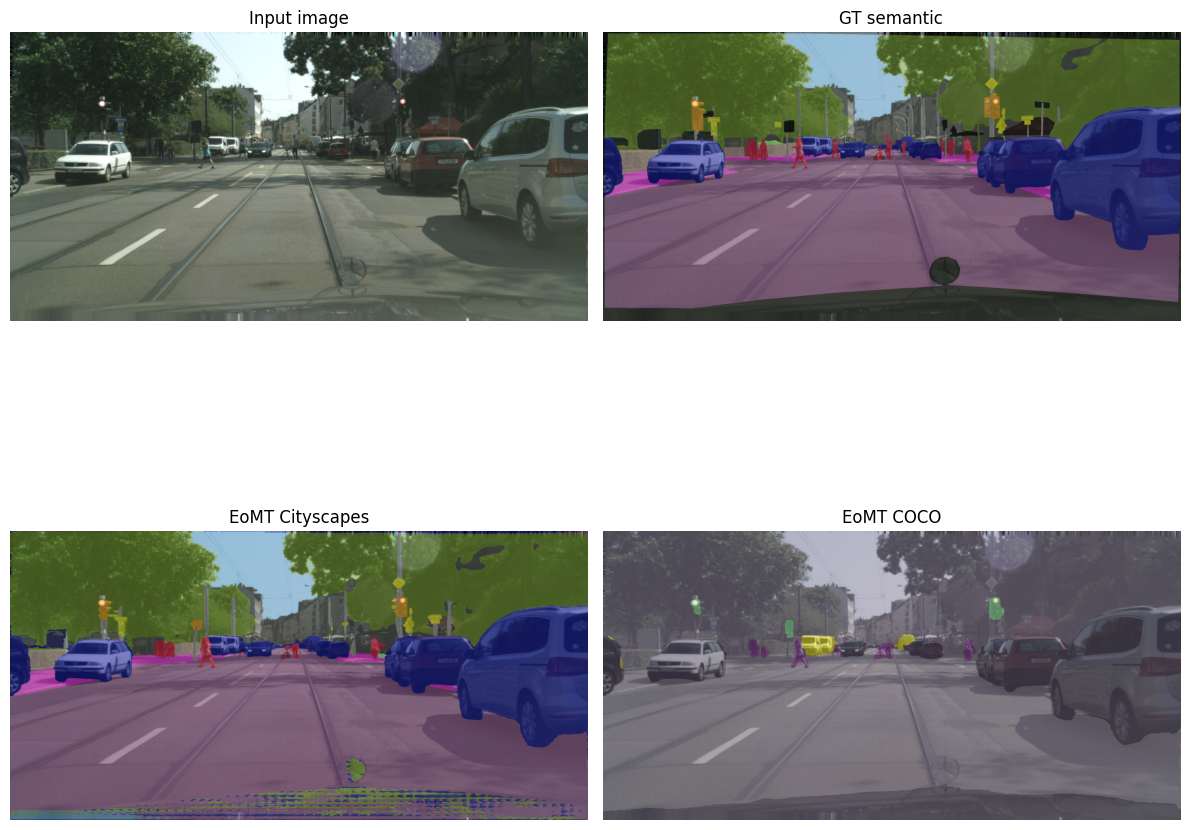

Saved: /content/drive/MyDrive/FAIMDL_PROJECT/report_figures_step4/step4_visual_comparison_003.png


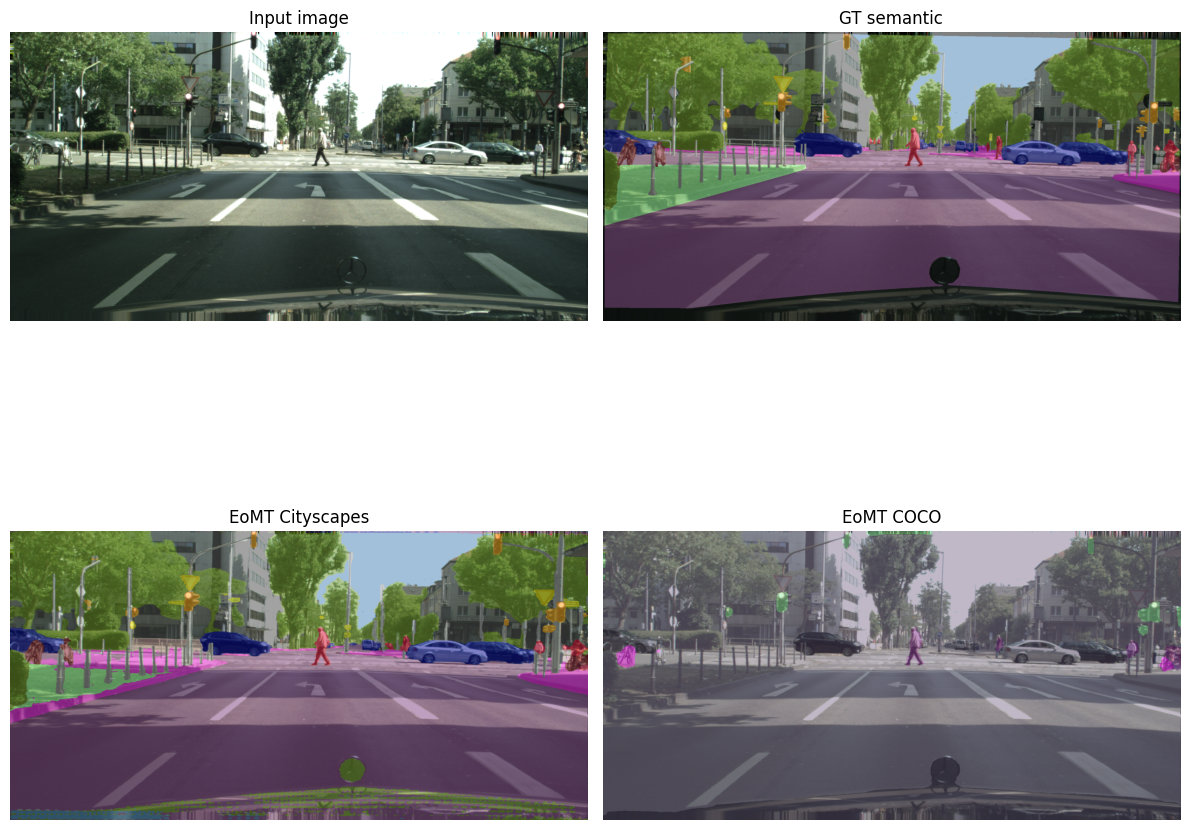

Saved: /content/drive/MyDrive/FAIMDL_PROJECT/report_figures_step4/step4_visual_comparison_015.png

Saved figures:
/content/drive/MyDrive/FAIMDL_PROJECT/report_figures_step4/step4_visual_comparison_003.png
/content/drive/MyDrive/FAIMDL_PROJECT/report_figures_step4/step4_visual_comparison_015.png


In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import cm
from PIL import Image

# ============================================================
# CONFIG
# ============================================================
SAVE_DIR = "/content/drive/MyDrive/FAIMDL_PROJECT/report_figures_step4"
os.makedirs(SAVE_DIR, exist_ok=True)

IGNORE_LABEL = 19

CITYSCAPES_CLASS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic light", "traffic sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train", "motorcycle", "bicycle"
]

CITYSCAPES_COLORS = np.array([
    [128,  64, 128],  # road
    [244,  35, 232],  # sidewalk
    [ 70,  70,  70],  # building
    [102, 102, 156],  # wall
    [190, 153, 153],  # fence
    [153, 153, 153],  # pole
    [250, 170,  30],  # traffic light
    [220, 220,   0],  # traffic sign
    [107, 142,  35],  # vegetation
    [152, 251, 152],  # terrain
    [ 70, 130, 180],  # sky
    [220,  20,  60],  # person
    [255,   0,   0],  # rider
    [  0,   0, 142],  # car
    [  0,   0,  70],  # truck
    [  0,  60, 100],  # bus
    [  0,  80, 100],  # train
    [  0,   0, 230],  # motorcycle
    [119,  11,  32],  # bicycle
], dtype=np.uint8)

# random palette
rng = np.random.default_rng(42)
INSTANCE_COLORS = rng.integers(0, 255, size=(500, 3), dtype=np.uint8)

# ============================================================
# HELPERS
# ============================================================
def denorm_img_tensor(img_t):
    # img_t: [3,H,W]
    img = img_t.detach().cpu().float()
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    return img

def colorize_semantic(label_map, colors=CITYSCAPES_COLORS, ignore_label=IGNORE_LABEL):
    h, w = label_map.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    valid = (label_map >= 0) & (label_map < len(colors))
    out[valid] = colors[label_map[valid]]
    out[label_map == ignore_label] = np.array([0, 0, 0], dtype=np.uint8)
    return out

def overlay_mask(image_rgb, mask_rgb, alpha=0.55):
    image_rgb = (image_rgb * 255).astype(np.uint8) if image_rgb.max() <= 1.0 else image_rgb.astype(np.uint8)
    out = ((1 - alpha) * image_rgb + alpha * mask_rgb).astype(np.uint8)
    return out

def build_gt_from_batch_single(batch, ignore_label=IGNORE_LABEL):
    rawtarget = batch[1]
    data_dict = rawtarget[0]
    masks = data_dict["masks"]
    trainids = data_dict["labels"]

    H, W = masks.shape[-2], masks.shape[-1]
    gtlabels = torch.full((H, W), ignore_label, dtype=torch.long)

    for i in range(len(masks)):
        tid = int(trainids[i])
        if 0 <= tid <= 18:
            gtlabels[masks[i]] = tid

    return gtlabels.cpu().numpy()

# ============================================================
# CITYSCAPES MODEL -> SEMANTIC PRED
# ============================================================
def infer_eomt_semantic(model_obj, img, img_size=None):
    device = next(model_obj.parameters()).device
    orig_hw = img.shape[-2:]
    target_hw = model_obj.img_size

    img_resized = F.interpolate(
        img.unsqueeze(0).float(),
        size=target_hw,
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)

    img_np = img_resized.detach().cpu().permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 255).astype(np.uint8)
    img_t = torch.from_numpy(img_np).permute(2, 0, 1).contiguous()

    with torch.no_grad():
        crops, origins = model_obj.window_imgs_semantic([img_t])
        crops = crops.to(device) if isinstance(crops, torch.Tensor) else [c.to(device) for c in crops]
        mask_logits_layer, class_logits_layer = model_obj(crops)
        crop_logits = model_obj.to_per_pixel_logits_semantic(
            mask_logits_layer[-1], class_logits_layer[-1]
        )
        logits = F.interpolate(
            crop_logits[0].unsqueeze(0),
            size=orig_hw,
            mode="bilinear",
            align_corners=False,
        ).squeeze(0)  # [C, H_orig, W_orig]

    pred = logits.argmax(dim=0).cpu().numpy()
    return pred, logits.cpu()

# ============================================================
# COCO MODEL -> PANOPTIC PRED
# ============================================================
def panoptic_palette_from_ids(semantic_ids, instance_ids):
    h, w = semantic_ids.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)

    for sem_id in np.unique(semantic_ids):
        mask_sem = semantic_ids == sem_id

        if sem_id < len(CITYSCAPES_COLORS):
            base_color = CITYSCAPES_COLORS[sem_id].astype(np.int32)
        else:
            base_color = np.array([128, 128, 128], dtype=np.int32)

        insts = np.unique(instance_ids[mask_sem])
        for k, inst_id in enumerate(insts):
            mask = mask_sem & (instance_ids == inst_id)
            jitter = INSTANCE_COLORS[int(inst_id) % len(INSTANCE_COLORS)].astype(np.int32) // 6
            color = np.clip(base_color + jitter - 20, 0, 255).astype(np.uint8)
            out[mask] = color

    return out

def infer_eomt_panoptic_coco(model_obj, img):
    model_obj.eval()
    with torch.no_grad():
        img_in = img.to(device)

        if hasattr(model_obj, "window_imgs_panoptic") and hasattr(model_obj, "revert_window_logits_panoptic"):
            crops, origins = model_obj.window_imgs_panoptic([img_in])
            outputs = model_obj(crops)

            if isinstance(outputs, (tuple, list)) and len(outputs) >= 2:
                mask_logits_per_layer, class_logits_per_layer = outputs[:2]
            else:
                raise RuntimeError("Output panoptic non riconosciuto")

            mask_logits = F.interpolate(
                mask_logits_per_layer[-1],
                tuple(img_in.shape[-2:]),
                mode="bilinear",
                align_corners=False,
            )

            if hasattr(model_obj, "to_per_pixel_logits_panoptic"):
                crop_logits = model_obj.to_per_pixel_logits_panoptic(
                    mask_logits,
                    class_logits_per_layer[-1],
                )
                logits = model_obj.revert_window_logits_panoptic(
                    crop_logits, origins, [img_in.shape[-2:]]
                )[0]
                semantic_pred = logits.argmax(0).cpu().numpy()

                instance_ids = np.zeros_like(semantic_pred)
                panoptic_rgb = panoptic_palette_from_ids(semantic_pred, instance_ids)
                return panoptic_rgb, semantic_pred, instance_ids

        pred_sem, _ = infer_eomt_semantic(model_obj, img, img_size=(640, 640))
        instance_ids = np.zeros_like(pred_sem)
        panoptic_rgb = panoptic_palette_from_ids(pred_sem, instance_ids)
        return panoptic_rgb, pred_sem, instance_ids

# ============================================================
# FIGURE
# ============================================================
def make_report_figure_from_batch(batch, idx, city_model, coco_model, save_dir=SAVE_DIR):
    img = batch[0][0]  # [3,H,W]
    img_np = to_display_rgb(img)
    gt_np = build_gt_from_batch_single(batch)

    pred_city, logits_city = infer_eomt_semantic(city_model, img, img_size=None)
    pred_city_rgb = colorize_semantic(pred_city)
    gt_rgb = colorize_semantic(gt_np)

    panoptic_rgb, coco_sem_proxy, coco_inst = infer_eomt_panoptic_coco(coco_model, img)

    gt_overlay = overlay_mask(img_np, gt_rgb, alpha=0.50)
    city_overlay = overlay_mask(img_np, pred_city_rgb, alpha=0.50)
    coco_overlay = overlay_mask(img_np, panoptic_rgb, alpha=0.50)

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))

    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Input image")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(gt_overlay)
    axes[0, 1].set_title("GT semantic")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(city_overlay)
    axes[1, 0].set_title("EoMT Cityscapes")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(coco_overlay)
    axes[1, 1].set_title("EoMT COCO")
    axes[1, 1].axis("off")

    plt.tight_layout()
    out_path = os.path.join(save_dir, f"step4_visual_comparison_{idx:03d}.png")
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_path}")
    return out_path

# ============================================================
# SAMPLE SELECTION
# ============================================================
def get_batch_by_index(loader, wanted_idx):
    for i, batch in enumerate(loader):
        if i == wanted_idx:
            return batch
    raise IndexError(f"Index {wanted_idx} fuori range")

sample_indices = [3, 15]

saved_paths = []
for idx in sample_indices:
    batch = get_batch_by_index(val_loader, idx)
    out_path = make_report_figure_from_batch(
        batch=batch,
        idx=idx,
        city_model=model,
        coco_model=model_coco,
        save_dir=SAVE_DIR,
    )
    saved_paths.append(out_path)

print("\nSaved figures:")
for p in saved_paths:
    print(p)